# CoMoCut - Analysis

**Author: Torsten Wüstenberg (CNSR) & Joel Grathwohl (ISSW)**

Goal: Describe the data extensively & compare left vs. right trials (mainly of central electrodes)

**1. Sensor Space** <br>
1.1. Time series of C3/C4; C1/C2; other areas<br>
1.2. Topomaps time series<br>
1.3. Time-frequency plots (C3/C4)<br>

**2. Source space (distributed source localisation)**<br>
2.1. Time series of M1; SMA; PPC; ...<br>
2.2. Topomaps time series<br>
2.3. Time-frequency plots (M1)<br>

**3. Data quality**<br>
3.1. SNR calculation (with resampling) (for number of available trials)<br>
3.2. Cross correlations for central channels (mainly C3/C4) at different time points (probably needs some frequency type analyses)<br>

**4. Other things to report**<br>
4.1. EOG Time series<br>
4.2. EMG time series (also use TP9/10 as reference??)<br>
4.3. Number of available and rejected trials<br>

### Preparations 

**Import libraries**

The analysis pipeline is based on the following libraries. In case of an error in the execution of this cell, probably one or more of the libraries is not installed. In this case, start a terminal in **ANACONDA.NAVIGATOR** *Environments>Terminal* and install the library in question using the command <span style='color: red'>*pip install [library name]*</span>.

In [3]:
import warnings                 # switch of pandas and mne warnings
warnings.simplefilter(action='ignore')

import requests
import os
import os.path as op
import time
import warnings

import mne

import numpy as np
import pandas as pd
import ipyfilechooser
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import pyprep
import math
import itertools
from datetime import datetime, timedelta
from datetime import datetime, timezone
from playsound import playsound
from openpyxl import load_workbook
from mne.export import export_raw
from mne.stats import permutation_cluster_test, permutation_cluster_1samp_test

from typing import Optional, Union
from collections import defaultdict
from mne.datasets import fetch_fsaverage
from mne.evoked import combine_evoked
from mne.forward import make_forward_dipole
from mne.simulation import simulate_evoked
from mne.viz import circular_layout
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle
from mne_icalabel import label_components
from mne_icalabel.gui import label_ica_components
from asrpy import ASR

from scipy.stats import ttest_rel
from scipy.stats import pearsonr
from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from itertools import combinations
from nilearn.image import index_img
from nilearn.plotting import plot_stat_map
from mne import read_evokeds
from mne.datasets import sample
from mne.minimum_norm import  make_inverse_operator, apply_inverse, read_inverse_operator, apply_inverse_epochs
from mpl_toolkits.axes_grid1 import make_axes_locatable

from npeet.entropy_estimators import mi as kraskov_mi
import itertools

from random import randint
import pingouin
import pickle

%matplotlib qt

mne.set_log_level("ERROR")  # only show errors (no warnings or information messages)

In [4]:
print(mne.__version__)

1.9.0


## 0. Loading data

In [7]:
wd = r"C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC"
fp = wd + os.sep + "20250703_Epochs_AMICA85_wATR"

# List of Fif file for left and right
eDl = []
for f in os.listdir(fp):
    if f.endswith(".fif") and "IC_left" in f:
        full_path = os.path.join(fp, f)
        if os.path.isfile(full_path):
            eDl.append(full_path)

eDr = []
for f in os.listdir(fp):
    if f.endswith(".fif") and "IC_right" in f:
        full_path = os.path.join(fp, f)
        if os.path.isfile(full_path):
            eDr.append(full_path)

# List of epoched data
epL = []
for e in eDl:
    eL = mne.read_epochs(e, preload = True)
    epL.append(eL)

epR = []
for e in eDr:
    eR = mne.read_epochs(e, preload = True)
    epR.append(eR)

### 0.0 Restricting data to (e.g. short ATR, early trials)
- ATR --> >1500 ms

#### Selection based on ATR

In [10]:
def choose_epochs_byatr(epochs, threshold, lower = True):
    # threshold: If None use mean_atr + std_atr --or-- if floeat: threshold = float (e.g. 500 ms = 500)
    # lower: If True, keeps epochs with ATR <= threshold // If False, keeps epochs with ATR >= threshold
    # Returns epochs with atr lower / higher than threshold

    # Get ATR
    atr_values = epochs.metadata.values

    # Calculate mean and standard deviation
    if threshold is None:
        mean_atr = np.mean(atr_values)
        std_atr = np.std(atr_values)
        threshold = mean_atr

    # Get indices for epochs to keep (ATR <= threshold)
    if lower:
        keep_indices = np.where(atr_values <= threshold)[0]
        print(f"{epochs.filename.name}: Selected {len(keep_indices)} epochs with atr <= {threshold:.3f} ms")
    else: 
        keep_indices = np.where(atr_values >= threshold)[0]
        print(f"{epochs.filename.name}: Selected {len(keep_indices)} epochs with atr >= {threshold:.3f} ms")

    # Filter the epochs
    filtered_epochs = epochs[keep_indices]

    return filtered_epochs

In [11]:
sel_epL = []
sel_epR = []

for e in epL:
    sel_epochs = choose_epochs_byatr(e, threshold = 1500, lower = True)
    sel_epL.append(sel_epochs)
    
for e in epR:
    sel_epochs = choose_epochs_byatr(e, threshold = 1500, lower = True)
    sel_epR.append(sel_epochs)

A37_IC_left_epochs_amica.fif: Selected 61 epochs with atr <= 1500.000 ms
B16_IC_left_epochs_amica.fif: Selected 61 epochs with atr <= 1500.000 ms
D31_IC_left_epochs_amica.fif: Selected 57 epochs with atr <= 1500.000 ms
E85_IC_left_epochs_amica.fif: Selected 53 epochs with atr <= 1500.000 ms
F48_IC_left_epochs_amica.fif: Selected 36 epochs with atr <= 1500.000 ms
G09_IC_left_epochs_amica.fif: Selected 55 epochs with atr <= 1500.000 ms
G26_IC_left_epochs_amica.fif: Selected 60 epochs with atr <= 1500.000 ms
H18_IC_left_epochs_amica.fif: Selected 65 epochs with atr <= 1500.000 ms
H29_IC_left_epochs_amica.fif: Selected 46 epochs with atr <= 1500.000 ms
I53_IC_left_epochs_amica.fif: Selected 66 epochs with atr <= 1500.000 ms
I72_IC_left_epochs_amica.fif: Selected 58 epochs with atr <= 1500.000 ms
L37_IC_left_epochs_amica.fif: Selected 62 epochs with atr <= 1500.000 ms
L67_IC_left_epochs_amica.fif: Selected 51 epochs with atr <= 1500.000 ms
M29_IC_left_epochs_amica.fif: Selected 62 epochs wi

#### Apply selection

In [15]:
# Make selected epL/epR list (so further code works)
epL = sel_epL
epR = sel_epR

In [16]:
# List of evoked data & kick IDs with 0 epochs out of epL/epR
for ep in epL:
    if len(ep) == 0:
        print(f"No epochs left after preprocessing in {os.path.basename(ep.filename)}")
epL = [ep for ep in epL if len(ep) > 0]  # Remove empty epochs

evL = []
evL_sem = []
for ep in epL:
    ev = ep.average()
    ev_sem = ep.standard_error()
    evL.append(ev)
    evL_sem.append(ev_sem)



for ep in epR:
    if len(ep) == 0:
        print(f"No epochs left after preprocessing in {os.path.basename(ep.filename)}")
epR = [ep for ep in epR if len(ep) > 0]  # Remove empty epochs

evR = []
evR_sem = []
for ep in epR:
    ev = ep.average()
    ev_sem = ep.standard_error()
    evR.append(ev)
    evR_sem.append(ev_sem)


## 1. Source Localisation

**Two ways: Trial average, then source loc ---OR--- source loc for each trial**

1) Forward solution
2) Inverse solution
   
   a) Covariance at baseline (-5 to -3s)
   
   b) Whitening: Lambda = 1 / SNR^2 --> Lambda = 0,11 is very trustworthy data, 1 is very noisy

       - Try: Lambda = 0.25 (SNR = 2)
       - Cross-validation: i) MNE.compute_variance: Parameter cv =3 (3-fold cross-validation) OR ii) Compare Lambdas OR iii) L-curve method

4) Make inverse operator (loose = 0.2; depth = 0.8)
5) Apply inverse operator

In [42]:
fs_dir

NameError: name 'fs_dir' is not defined

#### Load forward solution

In [22]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = "fsaverage"
trans = "fsaverage"
src = op.join(fs_dir, "bem", "fsaverage-ico-5-src.fif")
bem = op.join(fs_dir, "bem", "fsaverage-5120-5120-5120-bem-sol.fif")

0 files missing from root.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data\fsaverage


In [24]:
def load_forw():
    sourceLoc_dir = wd + os.sep + "20260128_SourceLoc"
    fname_fwd = sourceLoc_dir + os.sep + f'fsaverage-fwd.fif'
    fwd = mne.read_forward_solution(fname_fwd)

    return fwd

#### Make forward solution (only once)
Last update: 20260128

In [55]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = "fsaverage"
trans = "fsaverage"
src = op.join(fs_dir, "bem", "fsaverage-ico-5-src.fif")
bem = op.join(fs_dir, "bem", "fsaverage-5120-5120-5120-bem-sol.fif")

0 files missing from root.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data\fsaverage


In [57]:
fwd = mne.make_forward_solution(epochs.info, 
                                            trans = trans,
                                            src = src,
                                            bem = bem,
                                            eeg = True,
                                            mindist = 5.0,
                                            n_jobs = None
                                           )

In [58]:
mne.viz.plot_alignment(
    epochs.info,
    src=src,
    eeg=["original", "projected"],
    trans=trans,
    show_axes=True,
    mri_fiducials=True,
    dig="fiducials",
)

False


In [ ]:
# Check sensitivity

leadfield = fwd['sol']['data']
print(f"\nLead field matrix shape: {leadfield.shape}")
print(f"  {leadfield.shape[0]} sensors × {leadfield.shape[1]} source orientations")

# Compute and visualize sensitivity map
sensitivity_map = mne.sensitivity_map(
    fwd,
    ch_type='eeg',
    mode='free'  # or 'fixed' if using fixed orientations
)

# Plot sensitivity on brain surface
brain = sensitivity_map.plot(
    subject='fsaverage',
    subjects_dir=subjects_dir,
    time_label='EEG sensitivity',
    clim=dict(kind='percent', lims=[0, 50, 100])
)

In [187]:
# Save the forward solution
ID = epochs.filename.name.split("_")[0]
sourceLoc_dir = wd + os.sep + "20260128_SourceLoc"
os.makedirs(sourceLoc_dir, exist_ok = True)

output_file = sourceLoc_dir + os.sep + f'fsaverage-fwd.fif'
mne.write_forward_solution(output_file, fwd, overwrite=True)

### Covariances

In [26]:
def compute_covariance(epochs):
    
    # Compute rank directly from data
    rank = mne.compute_rank(
        epochs, 
        tol=1e-6,      # Tolerance for considering eigenvalue as zero
        tol_kind='relative'  # or 'absolute'
    )
    print(f"Rank of data: {rank}")

    # Use rank for covariance estimation
    noise_cov = mne.compute_covariance(
        epochs,
        tmin=-5.0, tmax=-3.0,  # here -5 to -3 is the baseline -> Participants standing still
        method='auto',
        rank=rank,  # ← Use computed rank
        verbose=True
    )

    # Plot
    #fig_cov, fig_spectra = mne.viz.plot_cov(noise_cov, epochs.info)

    return noise_cov

### Inverse solution

In [29]:
def make_inv(epochs, noise_cov, loose):
    inverse_operator = make_inverse_operator(
        epochs.info, 
        fwd, 
        noise_cov, 
        loose = loose, #default = 0.2 -> 0.0 == "fixed"
        depth = 0.8  #default
    )

    return inverse_operator

In [31]:
def apply_inv(epochs, method, snr):
    epo = epochs.set_eeg_reference("average", projection = True)
    evoked = epo.average()
    
    method = method  # could choose "dSPM", "MNE", "sLORETA", or "eLORETA" instead
    snr = snr          # 3 = very good (averaged, many trials); 2 = medium; 1 = bad (single trials)
    lambda2 = 1.0 / snr**2
    stc, residual = apply_inverse(
        evoked,
        inverse_operator,
        lambda2,
        method=method,
        pick_ori=None,
        return_residual=True,
        verbose=True,
    )

    return stc, residual

In [33]:
def visualize_brain(stc):
    vertno_max, time_max = stc.get_peak(hemi=None)
    
    fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
    subjects_dir = op.dirname(fs_dir)
    surfer_kwargs = dict(
        hemi="both",
        subjects_dir=subjects_dir,
        clim=dict(kind="value", lims=[3, 20, 50]),
        views="lateral",
        initial_time=time_max,
        time_unit="s",
        size=(800, 600),
        smoothing_steps=7,
    )
    brain = stc.plot(**surfer_kwargs)
    brain.add_foci(
        vertno_max,
        coords_as_verts=True,
        hemi="rh",
        color="blue",
        scale_factor=0.6,
        alpha=0.5,
    )
    brain.add_text(
        0.1, 0.9, f"{method} (plus location of maximal activation)", "title", font_size=14
    )

# The documentation website's movie is generated with:
# brain.save_movie(..., tmin=0.05, tmax=0.15, interpolation='linear',
#                  time_dilation=20, framerate=10, time_viewer=True)

In [35]:
# Compute individual source time courses 
side = "Right" # "Left" OR "Right"

fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
fwd = load_forw()

sourceLoc_dir = wd + os.sep + "20260128_SourceLoc"
#sourceLoc_dir = wd + os.sep + "20260205_AMICA50_SourceLoc"

if side == "Left":
    epoch_list = epL
else:
    epoch_list = epR


stcs = []
for e in epoch_list:
    ID = e.filename.name.split("_")[0]
    noise_cov = compute_covariance(e)
    inverse_operator = make_inv(e, noise_cov, 0.2)
    stc, residual = apply_inv(e, method = "dSPM", snr = 3.0)
    
    stcs.append(stc)

    # Save stc and residual
    fname_stc = sourceLoc_dir + os.sep + f'{ID}_{side}_stc'
    stc.save(fname_stc, ftype='h5', overwrite=True)
    fname_res = sourceLoc_dir + os.sep + f'{ID}_{side}_residual.npz'
    np.savez(fname_res, 
         data=residual.data, 
         times=residual.times)


0 files missing from root.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data\fsaverage
Rank of data: {'eeg': 32}
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 32
Estimating covariance using SHRUNK
Done.
Estimating covariance using DIAGONAL_FIXED
    EEG regularization : 0.1
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
    EEG regularization : 0.1
    EEG regularization : 0.1
    EEG regularization : 0.1
Number of samples used : 65065
log-likelihood on unseen data (descending order):
   shrunk: -84.513
   empirical: -84.566
   diagonal_fixed: -92.536
selecting best estimator: shrunk
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 60
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener usi

KeyboardInterrupt: 

In [39]:
# Load stc
side = "Left" # Left or Right
if side == "Left":
    epoch_list = epL
else:
    epoch_list = epR

sourceLoc_dir = wd + os.sep + "20260128_SourceLoc"
#sourceLoc_dir = wd + os.sep + "20260205_AMICA50_SourceLoc"

stcs = []
for e in epoch_list:
    ID = e.filename.name.split("_")[0]
    fname_stc = sourceLoc_dir + os.sep + f'{ID}_{side}_stc'
    stc = mne.read_source_estimate(fname_stc)
    #fname_res = sourceLoc_dir + os.sep + f'{ID}_{side}_residual.npz'
    #data = np.load(fname_res)
    #residual = data['data']
    stcs.append(stc)

In [40]:
## Visualization
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

# Morph into same head model ------> here not necessary (because all are "fsaverage")
morph = mne.compute_source_morph(
    stcs[0],  # Use first STC as template
    subject_from='fsaverage',
    subject_to='fsaverage',
    subjects_dir = op.dirname(fs_dir),
    #smooth=5,  # Optional: smooth during morphing
    verbose=True
)
stcs_morphed = [morph.apply(stc) for stc in stcs]

# Average Source time courses
stc_avg = sum(stcs_morphed) / len(stcs_morphed)

# Visualize
surfer_kwargs = dict(
    hemi="both",
    surface = "pial",
    subjects_dir=subjects_dir,
    clim=dict(kind="value", lims=[1, 25, 50]),
    views="lateral",
    initial_time=0.0,  # Or find peak
    time_unit="s",
    size=(800, 600),
    smoothing_steps=5,
)

brain = stc_avg.plot(**surfer_kwargs)
brain.add_text(0.1, 0.9, f"Group Average (N={len(epoch_list)}) // {side}", f"MRCP", font_size=16)

0 files missing from root.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data\fsaverage
surface source space present ...
Computing morph matrix...
    Left-hemisphere map read.
    Right-hemisphere map read.
    2 smooth iterations done.
    2 smooth iterations done.
[done]
[done]
False


#### Check with one individual

In [44]:
e = epL[0]

In [46]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

fwd = load_forw()
ID = e.filename.name.split("_")[0]
noise_cov = compute_covariance(e)
inverse_operator = make_inv(e, noise_cov, 0.0)
stc, residual = apply_inv(e, "sLORETA", snr = 2)

surfer_kwargs = dict(
    hemi="both",
    subjects_dir=subjects_dir,
    clim=dict(kind="value", lims=[0, 20, 50]),
    views="lateral",
    initial_time=-0.05,  # Or find peak
    time_unit="s",
    size=(800, 600),
    smoothing_steps=5,
)

brain = stc.plot(**surfer_kwargs)
brain.add_text(0.1, 0.9, f"{ID}", f"MRCP", font_size=16)

0 files missing from root.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\joelg\mne_data\MNE-fsaverage-data\fsaverage
Rank of data: {'eeg': 57}
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 57
Estimating covariance using SHRUNK
Done.
Estimating covariance using DIAGONAL_FIXED
    EEG regularization : 0.1
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
    EEG regularization : 0.1
    EEG regularization : 0.1
    EEG regularization : 0.1
Number of samples used : 66066
log-likelihood on unseen data (descending order):
   shrunk: -126.129
   empirical: -126.213
   diagonal_fixed: -142.155
selecting best estimator: shrunk
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 61
    Created the regularized inverter
    Created an SSP operator (su

## 1. Sensor space analysis

In [46]:
# Plot for one electrode
chan = "C4"
μV = 1e6  # volts to microvolts
sns.set(style="ticks")

evoked_data_left = []
evoked_data_right = []

for ev in evL:
    if ev is not None and chan in ev.ch_names:
        ch_idx = ev.ch_names.index(chan)
        evoked_data_left.append(ev.data[ch_idx] * μV)

for ev in evR:
    if ev is not None and chan in ev.ch_names:
        ch_idx = ev.ch_names.index(chan)
        evoked_data_right.append(ev.data[ch_idx] * μV)

# --- Time axis ---
times = evL[0].times if evL and evL[0] is not None else evR[0].times

# --- Group-level ATR markers from metadata ---
rt_l = [np.mean(ep.metadata.values) for ep in epL if ep.metadata is not None and not ep.metadata.empty]
rt_r = [np.mean(ep.metadata.values) for ep in epR if ep.metadata is not None and not ep.metadata.empty]

mean_rt_l, std_rt_l = (np.mean(rt_l) / 1000, np.std(rt_l) / 1000) if rt_l else (None, None)
mean_rt_r, std_rt_r = (np.mean(rt_r) / 1000, np.std(rt_r) / 1000) if rt_r else (None, None)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))

# Left condition
if evoked_data_left:
    data_left = np.vstack(evoked_data_left)
    mean_left = data_left.mean(axis=0)
    std_left = data_left.std(axis=0)
    label_l = f"Left Leg (n={len(data_left)})\nATR = {mean_rt_l*1000:.1f} ± {std_rt_l*1000:.1f} ms" if mean_rt_l is not None else f"Left (n={len(data_left)})"
    ax.plot(times, mean_left, color='red', label=label_l, linewidth=2)
    ax.fill_between(times, mean_left - std_left, mean_left + std_left, color='red', alpha=0.1)
    if mean_rt_l is not None:
        ax.axvline(-mean_rt_l, color='red', linestyle=':', linewidth=1.5, alpha=0.4)
        ax.axvspan(-mean_rt_l - std_rt_l, -mean_rt_l + std_rt_l, color='red', alpha=0.15)

# Right condition
if evoked_data_right:
    data_right = np.vstack(evoked_data_right)
    mean_right = data_right.mean(axis=0)
    std_right = data_right.std(axis=0)
    label_r = f"Right Leg (n={len(data_right)})\nATR = {mean_rt_r*1000:.1f} ± {std_rt_r*1000:.1f} ms" if mean_rt_r is not None else f"Right (n={len(data_right)})"
    ax.plot(times, mean_right, color='blue', label=label_r, linewidth=2)
    ax.fill_between(times, mean_right - std_right, mean_right + std_right, color='blue', alpha=0.1)
    if mean_rt_r is not None:
        ax.axvline(-mean_rt_r, color='blue', linestyle='-.', linewidth=1.5, alpha=0.4)
        ax.axvspan(-mean_rt_r - std_rt_r, -mean_rt_r + std_rt_r, color='blue', alpha=0.15)

# --- Formatting ---
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
#ax.grid(False)
#ax.set_ylim(y_min, y_max)
ax.set_title(f'Group Average MRCP at {chan}', fontsize=18)
ax.set_xlabel('Time (s)', fontsize = 14)
ax.set_ylabel('Amplitude (µV)', fontsize = 14)
ax.legend(loc='upper left', fontsize=16)
plt.tight_layout()
plt.show()


##### Get Min & Max of group-averaged MRCP

In [86]:
chan = "C4"
μV = 1e6  # volts to microvolts

# --- Crop individual evoked responses ---
evL_cropped = [ev.copy().crop(-2, 0) for ev in evL]
evR_cropped = [ev.copy().crop(-2, 0) for ev in evR]

# --- Extract channel data for each individual subject ---
def get_channel_data(evoked):
    ch_idx = evoked.ch_names.index(chan)
    return evoked.data[ch_idx] * μV

# Get individual subject data
data_left_subjects = [get_channel_data(ev) for ev in evL_cropped]
data_right_subjects = [get_channel_data(ev) for ev in evR_cropped]

# Convert to arrays for easier manipulation
data_left_array = np.array(data_left_subjects)  # Shape: (n_subjects, n_timepoints)
data_right_array = np.array(data_right_subjects)

# --- Compute group averages ---
data_left_mean = np.mean(data_left_array, axis=0)
data_right_mean = np.mean(data_right_array, axis=0)

# --- Compute standard deviation across subjects at each timepoint ---
data_left_std = np.std(data_left_array, axis=0, ddof=1)
data_right_std = np.std(data_right_array, axis=0, ddof=1)

# --- Find minima and maxima of group averages with their SDs ---
def get_extrema_with_sd(mean_data, std_data):
    min_idx = np.argmin(mean_data)
    max_idx = np.argmax(mean_data)
    
    min_value = mean_data[min_idx]
    max_value = mean_data[max_idx]
    
    min_sd = std_data[min_idx]
    max_sd = std_data[max_idx]
    
    return {
        "min_value": min_value,
        "min_sd": min_sd,
        "min_time_idx": min_idx,
        "max_value": max_value,
        "max_sd": max_sd,
        "max_time_idx": max_idx
    }

# --- Extract extrema for both conditions ---
left_extrema = get_extrema_with_sd(data_left_mean, data_left_std)
right_extrema = get_extrema_with_sd(data_right_mean, data_right_std)

# --- Get time axis for reference ---
evL_ave = mne.combine_evoked(evL, weights="equal").crop(-2, 0)
times = evL_ave.times

# --- Summary ---
summary = {
    "Left": {
        "min": left_extrema["min_value"],
        "min_sd": left_extrema["min_sd"],
        "min_time": times[left_extrema["min_time_idx"]],
        "max": left_extrema["max_value"],
        "max_sd": left_extrema["max_sd"],
        "max_time": times[left_extrema["max_time_idx"]]
    },
    "Right": {
        "min": right_extrema["min_value"],
        "min_sd": right_extrema["min_sd"],
        "min_time": times[right_extrema["min_time_idx"]],
        "max": right_extrema["max_value"],
        "max_sd": right_extrema["max_sd"],
        "max_time": times[right_extrema["max_time_idx"]]
    }
}

# --- Print results ---
print("Group-averaged extrema with standard deviations:")
for condition in ["Left", "Right"]:
    print(f"\n{condition}:")
    print(f"  Minimum: {summary[condition]['min']:.2f} ± {summary[condition]['min_sd']:.2f} μV "
          f"at t = {summary[condition]['min_time']:.3f} s")
    print(f"  Maximum: {summary[condition]['max']:.2f} ± {summary[condition]['max_sd']:.2f} μV "
          f"at t = {summary[condition]['max_time']:.3f} s")

summary

Group-averaged extrema with standard deviations:

Left:
  Minimum: -2.79 ± 4.01 μV at t = -0.260 s
  Maximum: 4.03 ± 4.25 μV at t = -0.040 s

Right:
  Minimum: -2.54 ± 4.32 μV at t = -0.012 s
  Maximum: 2.44 ± 2.62 μV at t = -0.448 s


{'Left': {'min': -2.7906722056327657,
  'min_sd': 4.013598628640458,
  'min_time': -0.26,
  'max': 4.0288939980647465,
  'max_sd': 4.248876806582266,
  'max_time': -0.04},
 'Right': {'min': -2.538375165689423,
  'min_sd': 4.3199953004399045,
  'min_time': -0.012,
  'max': 2.4410399855943634,
  'max_sd': 2.6229797632471623,
  'max_time': -0.448}}

In [48]:
# Updated code with 95%-CI

μV = 1e6  # volts to microvolts
channels = ["C3", "C4"]
colors = {"Left": "red", "Right": "blue"}
sns.set(style="ticks")

# --- Function to collect data per channel and side ---
def get_evoked_data(evoked_list, channel):
    data = []
    for ev in evoked_list:
        if ev is not None and channel in ev.ch_names:
            ch_idx = ev.ch_names.index(channel)
            data.append(ev.data[ch_idx] * μV)
    return data

# --- Function to compute ATR stats from metadata ---
def get_atr_stats(epochs):
    atrs = [np.mean(ep.metadata.values) for ep in epochs if ep.metadata is not None and not ep.metadata.empty]
    if not atrs:
        return None, None, None, None

    n = len(atrs)
    mean_atr = np.mean(atrs)
    std_atr = np.std(atrs, ddof=1)  # Use ddof=1 for sample SD
    sem_atr = std_atr / np.sqrt(n)
    
    # 95% CI using t-distribution
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci95_atr = t_crit * sem_atr
    
    return mean_atr, std_atr, sem_atr, ci95_atr 

# --- Time axis ---
times = (evL[0].times if evL and evL[0] is not None else evR[0].times) *1000

# --- Plotting both channels ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, chan in enumerate(channels):
    ax = axes[i]
    
    # Get evoked data
    evoked_left = get_evoked_data(evL, chan)
    evoked_right = get_evoked_data(evR, chan)

    # Get ATR stats
    mean_rt_l, std_rt_l, sem_rt_l, ci95_rt_l = get_atr_stats(epL)
    mean_rt_r, std_rt_r, sem_rt_r, ci95_rt_r = get_atr_stats(epR)

    # Plot Left
    if evoked_left:
        data_l = np.vstack(evoked_left)
        mean_l = data_l.mean(axis=0)
        std_l = data_l.std(axis=0, ddof = 1)
        sem_l = data_l.std(axis=0, ddof = 1)/np.sqrt(len(data_l))

        t_crit = stats.t.ppf(0.975, len(data_l)-1)  # 0.975 for two-tailed 95%
        ci95_l = t_crit * sem_l
        
        label_l = f"Left (N={len(data_l)})\nATR = {mean_rt_l:.1f} ± {std_rt_l:.1f} ms"
        ax.plot(times, mean_l, color=colors["Left"], label=label_l, linewidth=2)
        ax.fill_between(times, mean_l - ci95_l, mean_l + ci95_l, color=colors["Left"], alpha=0.1)
        ax.axvline(-mean_rt_l, color=colors["Left"], linestyle=':', linewidth=1.5, alpha=0.6)
        ax.axvspan(-mean_rt_l - ci95_rt_l, -mean_rt_l + ci95_rt_l, color=colors["Left"], alpha=0.15)

    # Plot Right
    if evoked_right:
        data_r = np.vstack(evoked_right)
        mean_r = data_r.mean(axis=0)
        std_r = data_r.std(axis=0, ddof = 1)
        sem_r = data_r.std(axis=0, ddof = 1)/np.sqrt(len(data_r))

        t_crit = stats.t.ppf(0.975, len(data_r)-1)  # 0.975 for two-tailed 95%
        ci95_r = t_crit * sem_r
        
        label_r = f"Right (N={len(data_r)})\nATR = {mean_rt_r:.1f} ± {std_rt_r:.1f} ms"
        ax.plot(times, mean_r, color=colors["Right"], label=label_r, linewidth=2)
        ax.fill_between(times, mean_r - ci95_r, mean_r + ci95_r, color=colors["Right"], alpha=0.1)
        ax.axvline(-mean_rt_r, color=colors["Right"], linestyle='-.', linewidth=1.5, alpha=0.6)
        ax.axvspan(-mean_rt_r - ci95_rt_r, -mean_rt_r + ci95_rt_r, color=colors["Right"], alpha=0.15)

    # Formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(0, color="k", linestyle = "-", linewidth = 1, alpha = 0.4)
    ax.set_title(f'{chan}', fontsize=18)
    ax.set_xlabel('Time (ms)', fontsize = 14)
    if i == 0:
        ax.set_ylabel('Amplitude (µV)', fontsize = 14)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


In [43]:
# Plotting without ATR information box
# SEM instead of STD
# & high alpha for each side

μV = 1e6  # volts to microvolts
channels = ["C3", "C4"]
colors = {"Left": "red", "Right": "blue"}
sns.set(style="ticks")

# --- Function to collect data per channel and side ---
def get_evoked_data(evoked_list, channel):
    data = []
    for ev in evoked_list:
        if ev is not None and channel in ev.ch_names:
            ch_idx = ev.ch_names.index(channel)
            data.append(ev.data[ch_idx] * μV)
    return data

# --- Function to compute ATR stats from metadata ---
def get_atr_stats(epochs):
    atrs = [np.mean(ep.metadata.values) for ep in epochs if ep.metadata is not None and not ep.metadata.empty]
    if not atrs:
        return None, None
    return np.mean(atrs), np.std(atrs), np.std(atrs)/np.sqrt(len(atrs))

# --- Time axis ---
times = (evL[0].times if evL and evL[0] is not None else evR[0].times) *1000

# --- Plotting both channels ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, chan in enumerate(channels):
    ax = axes[i]
    
    # Get evoked data
    evoked_left = get_evoked_data(evL, chan)
    evoked_right = get_evoked_data(evR, chan)

    # Get ATR stats
    mean_rt_l, std_rt_l, sem_rt_l = get_atr_stats(epL)
    mean_rt_r, std_rt_r, sem_rt_r = get_atr_stats(epR)

    # Plot Left
    if evoked_left:
        data_l = np.vstack(evoked_left)
        mean_l = data_l.mean(axis=0)
        std_l = data_l.std(axis=0)
        sem_l = data_l.std(axis=0)/np.sqrt(len(data_l))
        label_l = f"Left Leg\n(Mean ± SEM)"
        ax.plot(times, mean_l, color=colors["Left"], label=label_l, linewidth=2) # , alpha = 0.3
        ax.fill_between(times, mean_l - sem_l, mean_l + sem_l, color=colors["Left"], alpha=0.1) # alpha=0.03
        ax.axvline(-mean_rt_l, color=colors["Left"], linestyle=':', linewidth=1.5, alpha=0.6) # alpha=0.02
        ax.axvspan(-mean_rt_l - sem_rt_l, -mean_rt_l + sem_rt_l, color=colors["Left"], alpha=0.15) # alpha=0.05

    # Plot Right
    if evoked_right:
        data_r = np.vstack(evoked_right)
        mean_r = data_r.mean(axis=0)
        std_r = data_r.std(axis=0)
        sem_r = data_r.std(axis=0)/np.sqrt(len(data_r))
        label_r = f"Right Leg\n(Mean ± SEM)"
        ax.plot(times, mean_r, color=colors["Right"], label=label_r, linewidth=2)
        ax.fill_between(times, mean_r - sem_r, mean_r + sem_r, color=colors["Right"], alpha=0.1)
        ax.axvline(-mean_rt_r, color=colors["Right"], linestyle='-.', linewidth=1.5, alpha=0.6)
        ax.axvspan(-mean_rt_r - sem_rt_r, -mean_rt_r + sem_rt_r, color=colors["Right"], alpha=0.15)

    # Formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(0, color="k", linestyle = "-", linewidth = 1, alpha = 0.4)
    ax.set_title(f'{chan}', fontsize=18)
    ax.set_xlabel('Time (ms)', fontsize = 14)
    if i == 0:
        ax.set_ylabel('Amplitude (µV)', fontsize = 14)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


In [49]:
# Plotting without ATR information box
# SEM instead of STD
# y-axis with negative up
μV = 1e6  # volts to microvolts
channels = ["Fz", "Cz"]
colors = {"Left": "red", "Right": "blue"}
sns.set(style="ticks")
# --- Function to collect data per channel and side ---
def get_evoked_data(evoked_list, channel):
    data = []
    for ev in evoked_list:
        if ev is not None and channel in ev.ch_names:
            ch_idx = ev.ch_names.index(channel)
            data.append(ev.data[ch_idx] * μV)
    return data
# --- Function to compute ATR stats from metadata ---
def get_atr_stats(epochs):
    atrs = [np.mean(ep.metadata.values) for ep in epochs if ep.metadata is not None and not ep.metadata.empty]
    if not atrs:
        return None, None
    return np.mean(atrs), np.std(atrs), np.std(atrs)/np.sqrt(len(atrs))
# --- Time axis ---
times = (evL[0].times if evL and evL[0] is not None else evR[0].times) *1000
# --- Plotting both channels ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, chan in enumerate(channels):
    ax = axes[i]
    
    # Get evoked data
    evoked_left = get_evoked_data(evL, chan)
    evoked_right = get_evoked_data(evR, chan)
    # Get ATR stats
    mean_rt_l, std_rt_l, sem_rt_l = get_atr_stats(epL)
    mean_rt_r, std_rt_r, sem_rt_r = get_atr_stats(epR)
    # Plot Left
    if evoked_left:
        data_l = np.vstack(evoked_left)
        mean_l = data_l.mean(axis=0)
        std_l = data_l.std(axis=0)
        sem_l = data_l.std(axis=0)/np.sqrt(len(data_l))
        label_l = f"Left Leg\n(Mean ± SEM)"
        # ← CHANGED: Flip data sign so negative values plot upward with correct axis labels
        ax.plot(times, -mean_l, color=colors["Left"], label=label_l, linewidth=2) # , alpha = 0.3
        ax.fill_between(times, -(mean_l - sem_l), -(mean_l + sem_l), color=colors["Left"], alpha=0.1) # alpha=0.03
        ax.axvline(-mean_rt_l, color=colors["Left"], linestyle=':', linewidth=1.5, alpha=0.6) # alpha=0.02
        ax.axvspan(-mean_rt_l - sem_rt_l, -mean_rt_l + sem_rt_l, color=colors["Left"], alpha=0.15) # alpha=0.05
    # Plot Right
    if evoked_right:
        data_r = np.vstack(evoked_right)
        mean_r = data_r.mean(axis=0)
        std_r = data_r.std(axis=0)
        sem_r = data_r.std(axis=0)/np.sqrt(len(data_r))
        label_r = f"Right Leg\n(Mean ± SEM)"
        # ← CHANGED: Flip data sign so negative values plot upward with correct axis labels
        ax.plot(times, -mean_r, color=colors["Right"], label=label_r, linewidth=2)
        ax.fill_between(times, -(mean_r - sem_r), -(mean_r + sem_r), color=colors["Right"], alpha=0.1)
        ax.axvline(-mean_rt_r, color=colors["Right"], linestyle='-.', linewidth=1.5, alpha=0.6)
        ax.axvspan(-mean_rt_r - sem_rt_r, -mean_rt_r + sem_rt_r, color=colors["Right"], alpha=0.15)
    # Formatting
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(0, color="k", linestyle = "-", linewidth = 1, alpha = 0.4)
    
    # ← CHANGED: Proper EEG convention - invert y-axis AND fix tick labels
    ax.invert_yaxis()
    
    # ← CHANGED: Manually set y-tick labels to show correct polarity
    ylim = ax.get_ylim()
    yticks = ax.get_yticks()
    # Flip the sign of tick labels so they represent the actual EEG values
    ax.set_yticklabels([f'{-tick:.0f}' for tick in yticks])
    
    ax.set_title(f'{chan}', fontsize=18)
    ax.set_xlabel('Time (ms)', fontsize = 14)
    if i == 0:
        # ← CHANGED: Clearer ylabel for EEG convention
        ax.set_ylabel('Amplitude (µV)\n(negative up)', fontsize = 14)
    ax.legend(loc='upper left', fontsize=16)
plt.tight_layout()
plt.show()

In [35]:
ch = "C4"

def prepare_data_for_cbpt(evL, evR, chan=ch):
    """
    Prepare data for cluster-based permutation testing
    
    Parameters:
    -----------
    evL : list of Evoked objects for left condition
    evR : list of Evoked objects for right condition  
    chan : str, channel name to analyze
    
    Returns:
    --------
    X : array, shape (n_subjects, n_times) - Left condition data
    Y : array, shape (n_subjects, n_times) - Right condition data
    times : array, time points
    """
    μV = 1e6  # volts to microvolts
    
    # Extract data for left condition
    evoked_data_left = []
    for ev in evL:
        if ev is not None and chan in ev.ch_names:
            ch_idx = ev.ch_names.index(chan)
            evoked_data_left.append(ev.data[ch_idx] * μV)
    
    # Extract data for right condition  
    evoked_data_right = []
    for ev in evR:
        if ev is not None and chan in ev.ch_names:
            ch_idx = ev.ch_names.index(chan)
            evoked_data_right.append(ev.data[ch_idx] * μV)
    
    # Get time axis
    times = evL[0].times if evL and evL[0] is not None else evR[0].times
    
    # Convert to arrays
    X = np.array(evoked_data_left)  # Shape: (n_subjects, n_times)
    Y = np.array(evoked_data_right)  # Shape: (n_subjects, n_times)
    
    return X, Y, times

def run_cluster_permutation_test(X, Y, times, n_permutations=1000, alpha=0.05, 
                                tail=0, n_jobs=1):
    """
    Run cluster-based permutation test between two conditions
    
    Parameters:
    -----------
    X, Y : arrays of shape (n_subjects, n_times)
    times : array, time points
    n_permutations : int, number of permutations (default 1000)
    alpha : float, significance level (default 0.05)
    tail : int, -1 (X < Y), 0 (X != Y), 1 (X > Y)
    n_jobs : int, number of parallel jobs
    
    Returns:
    --------
    T_obs : array, t-statistics at each time point
    clusters : list, significant clusters
    cluster_p_values : array, p-values for each cluster
    H0 : array, null distribution of max cluster statistics
    """
    
    print(f"Running cluster permutation test with {n_permutations} permutations...")
    print(f"Data shapes: X={X.shape}, Y={Y.shape}")
    print(f"Testing difference between conditions (tail={tail})")
    
    # Run the cluster-based permutation test
    T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        [X, Y], 
        n_permutations=n_permutations,
        threshold=None,  # Use t-distribution threshold
        tail=tail,
        n_jobs=n_jobs,
        seed=42  # For reproducibility
    )
    
    return T_obs, clusters, cluster_p_values, H0

def plot_cbpt_results(X, Y, times, T_obs, clusters, cluster_p_values, 
                     chan= ch, alpha=0.05):
    """
    Plot the results of cluster-based permutation test
    """
    
    # Calculate means and SEMs
    mean_X = np.mean(X, axis=0)
    mean_Y = np.mean(Y, axis=0)
    sem_X = stats.sem(X, axis=0)
    sem_Y = stats.sem(Y, axis=0)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot 1: Time series with significant clusters highlighted
    ax1.plot(times, mean_X, 'r-', linewidth=2, label=f'Left Leg (n={X.shape[0]})')
    ax1.fill_between(times, mean_X - sem_X, mean_X + sem_X, color='red', alpha=0.2)
    
    ax1.plot(times, mean_Y, 'b-', linewidth=2, label=f'Right Leg (n={Y.shape[0]})')
    ax1.fill_between(times, mean_Y - sem_Y, mean_Y + sem_Y, color='blue', alpha=0.2)
    
    # Highlight significant clusters
    y_min, y_max = ax1.get_ylim()
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            h = ax1.axvspan(times[c[0][0]], times[c[0][-1]], 
                           color='gold', alpha=0.3)
            ax1.text(times[c[0][0]] + (times[c[0][-1]] - times[c[0][0]])/2, 
                    y_max * 0.9, f'p={cluster_p_values[i_c]:.3f}', 
                    ha='center', fontweight='bold')
    
    ax1.axvline(0, color='k', linestyle='--', alpha=0.7)
    ax1.set_ylabel('Amplitude (µV)', fontsize=12)
    ax1.set_title(f'Group Average MRCP at {chan} with Significant Clusters', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: T-statistics
    ax2.plot(times, T_obs, 'k-', linewidth=1.5)
    ax2.axhline(0, color='k', linestyle='--', alpha=0.7)
    
    # Highlight significant clusters on t-stat plot
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            ax2.axvspan(times[c[0][0]], times[c[0][-1]], 
                       color='gold', alpha=0.3)
    
    ax2.axvline(0, color='k', linestyle='--', alpha=0.7)
    ax2.set_xlabel('Time (s)', fontsize=12)
    ax2.set_ylabel('T-statistic', fontsize=12)
    ax2.set_title('T-statistics (Left vs Right)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print results summary
    print(f"\n=== CLUSTER PERMUTATION TEST RESULTS ===")
    print(f"Channel: {chan}")
    print(f"Time window: {times[0]:.3f} to {times[-1]:.3f} s")
    print(f"Number of significant clusters (p < {alpha}): {sum(p <= alpha for p in cluster_p_values)}")
    
    for i_c, (c, p_val) in enumerate(zip(clusters, cluster_p_values)):
        if p_val <= alpha:
            start_time = times[c[0][0]]
            end_time = times[c[0][-1]]
            duration = end_time - start_time
            print(f"\nCluster {i_c+1}:")
            print(f"  Time range: {start_time:.3f} to {end_time:.3f} s ({duration*1000:.0f} ms)")
            print(f"  p-value: {p_val:.4f}")
            print(f"  Size: {len(c[0])} time points")
    
    if not any(p <= alpha for p in cluster_p_values):
        print("\nNo significant clusters found.")

def additional_analyses(X, Y, times, T_obs):
    """
    Additional analyses and effect size calculations
    """
    print(f"\n=== ADDITIONAL ANALYSES ===")
    
    # Cohen's d for effect size at each time point
    pooled_std = np.sqrt(((X.shape[0] - 1) * np.var(X, axis=0, ddof=1) + 
                         (Y.shape[0] - 1) * np.var(Y, axis=0, ddof=1)) / 
                        (X.shape[0] + Y.shape[0] - 2))
    cohens_d = (np.mean(X, axis=0) - np.mean(Y, axis=0)) / pooled_std
    
    # Find peak differences
    max_t_idx = np.argmax(np.abs(T_obs))
    peak_time = times[max_t_idx]
    peak_t = T_obs[max_t_idx]
    peak_cohens_d = cohens_d[max_t_idx]
    
    print(f"Peak difference at {peak_time:.3f} s:")
    print(f"  T-statistic: {peak_t:.3f}")
    print(f"  Cohen's d: {peak_cohens_d:.3f}")
    
    # Overall statistics
    print(f"\nOverall statistics:")
    print(f"  Mean Cohen's d: {np.mean(np.abs(cohens_d)):.3f}")
    print(f"  Max |Cohen's d|: {np.max(np.abs(cohens_d)):.3f}")

# Main analysis function
def analyze_conditions_cbpt(evL, evR, chan= ch, n_permutations=1000, 
                           alpha=0.05, tail=0):
    """
    Complete analysis pipeline for cluster-based permutation test
    """
    print(f"=== CLUSTER-BASED PERMUTATION TEST ANALYSIS ===")
    print(f"Channel: {chan}")
    
    # Prepare data
    X, Y, times = prepare_data_for_cbpt(evL, evR, chan)
    
    if X.size == 0 or Y.size == 0:
        print("Error: No valid data found for the specified conditions/channel")
        return
    
    # Run cluster permutation test
    T_obs, clusters, cluster_p_values, H0 = run_cluster_permutation_test(
        X, Y, times, n_permutations=n_permutations, alpha=alpha, tail=tail
    )
    
    # Plot results
    plot_cbpt_results(X, Y, times, T_obs, clusters, cluster_p_values, 
                     chan=chan, alpha=alpha)
    
    # Additional analyses
    additional_analyses(X, Y, times, T_obs)
    
    return {
        'X': X, 'Y': Y, 'times': times,
        'T_obs': T_obs, 'clusters': clusters, 
        'cluster_p_values': cluster_p_values, 'H0': H0
    }

# Example usage:
if __name__ == "__main__":
    # Run the analysis (assuming evL and evR are already defined)
    results = analyze_conditions_cbpt(evL, evR, chan= ch, 
                                     n_permutations=1000, 
                                     alpha=0.05, 
                                     tail=0)  # Two-tailed test
    
    # For one-tailed tests:
    # tail=1  # Test if Left > Right
    # tail=-1 # Test if Left < Right

=== CLUSTER-BASED PERMUTATION TEST ANALYSIS ===
Channel: C4
Running cluster permutation test with 1000 permutations...
Data shapes: X=(21, 1001), Y=(21, 1001)
Testing difference between conditions (tail=0)

=== CLUSTER PERMUTATION TEST RESULTS ===
Channel: C4
Time window: -2.000 to 0.000 s
Number of significant clusters (p < 0.05): 2

Cluster 15:
  Time range: -0.780 to -0.300 s (480 ms)
  p-value: 0.0010
  Size: 241 time points

Cluster 18:
  Time range: -0.180 to -0.006 s (174 ms)
  p-value: 0.0370
  Size: 88 time points

=== ADDITIONAL ANALYSES ===
Peak difference at -0.582 s:
  T-statistic: 32.882
  Cohen's d: -1.770

Overall statistics:
  Mean Cohen's d: 0.862
  Max |Cohen's d|: 1.770


In [37]:
def get_lrp(subj_nr):
    # Extract C3 and C4 data
    c3_left = evL[subj_nr].copy().pick_channels(['C3']).data[0]  # shape: (n_times,)
    c4_left = evL[subj_nr].copy().pick_channels(['C4']).data[0]
    
    c3_right = evR[subj_nr].copy().pick_channels(['C3']).data[0]
    c4_right = evR[subj_nr].copy().pick_channels(['C4']).data[0]
    
    lrp = ((c4_left - c3_left) + (c3_right - c4_right)) / 2 #(Coles, 1989)
    
    # LRP as evoked
    lrp_evoked = evL[subj_nr].copy().pick_channels(['C3']) # Use C3 as template and replace data
    lrp_evoked.data[0] = lrp
    lrp_evoked.comment = 'LRP'
    
    return lrp, lrp_evoked

In [39]:
 # Calculate LRP for all subjects
lrp_data = []
for i in range(len(evL)):
    lrp, lev = get_lrp(i)
    lrp_data.append(lrp)
    
    # Convert to array: (n_subjects, n_times)
    lrp_array = np.array(lrp_data)
    
    # Get time axis
    times = evL[0].times if evL and evL[0] is not None else evR[0].times
    
    print(f"Prepared LRP data: {lrp_array.shape[0]} subjects, {lrp_array.shape[1]} time points")
    print(f"Time range: {times[0]:.3f} to {times[-1]:.3f} seconds")

Prepared LRP data: 1 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 2 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 3 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 4 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 5 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 6 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 7 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 8 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 9 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 10 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 11 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Prepared LRP data: 12 subjects, 1001 time points
Time range: -2.000 to 0.0

In [41]:
# Get lrp data & Plotting
lrp_data = []
for i in range(len(evL)):
    l, lev = get_lrp(i)
    lrp_data.append(l)

# Configuration
μV = 1e6  # volts to microvolts
sns.set(style="ticks")

# Convert to array
lrp_array = np.array(lrp_data)  # Shape: (n_subjects, n_timepoints)

# --- Time axis ---
times = evL[0].times*1000 if evL and evL[0] is not None else evR[0].times *1000

# --- Group-level ATR markers from metadata ---
rt_l = [np.mean(ep.metadata.values) for ep in epL if ep.metadata is not None and not ep.metadata.empty]
rt_r = [np.mean(ep.metadata.values) for ep in epR if ep.metadata is not None and not ep.metadata.empty]
mean_rt_l, std_rt_l = (np.mean(rt_l), np.std(rt_l)) if rt_l else (None, None)
mean_rt_r, std_rt_r = (np.mean(rt_r), np.std(rt_r)) if rt_r else (None, None)
sem_rt_l = std_rt_l/np.sqrt(len(lrp_data))
sem_rt_r = std_rt_r/np.sqrt(len(lrp_data))

# Calculate mean ATR
mean_rt_combined = None
std_rt_combined = None
sem_rt_combined = None
if mean_rt_l is not None and mean_rt_r is not None:
    all_rts = rt_l + rt_r
    mean_rt_combined = np.mean(all_rts) 
    std_rt_combined = np.std(all_rts) 
    sem_rt_combined = std_rt_combined / np.sqrt(len(lrp_data))

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))

# LRP
if len(lrp_data) > 0:
    mean_lrp = lrp_array.mean(axis=0)
    std_lrp = lrp_array.std(axis=0, ddof=1)
    sem_lrp = std_lrp / np.sqrt(len(lrp_data))
    
    label_lrp = f"LRP (n={len(lrp_data)})"
    if mean_rt_combined is not None:
        label_lrp += f"\nATR = {mean_rt_combined:.1f} ± {std_rt_combined:.1f} ms"
    
    ax.plot(times, mean_lrp, color='blueviolet', label=label_lrp, linewidth=2)
    ax.fill_between(times, mean_lrp - sem_lrp, mean_lrp + sem_lrp, color='blueviolet', alpha=0.2)
    
    # ATR marker
    if mean_rt_combined is not None:
        ax.axvline(-mean_rt_combined, color='blueviolet', linestyle=':', linewidth=1.5, alpha=0.6)
        ax.axvspan(-mean_rt_combined - sem_rt_combined, -mean_rt_combined + sem_rt_combined, 
                   color='blueviolet', alpha=0.15)

# --- Formatting ---
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
#ax.grid(False)
#ax.set_ylim(y_min, y_max)
ax.set_title('LRP for C3 and C4', fontsize=18)
ax.set_xlabel('Time (ms)', fontsize=14)
ax.set_ylabel('Amplitude (μV)', fontsize=14)
ax.legend(loc='upper left', fontsize=16)
plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

In [70]:
min_idx = np.argmin(mean_lrp)
max_idx = np.argmax(mean_lrp)
print(f"Min: {mean_lrp[min_idx]*1e6:.2f} ± {std_lrp[min_idx]*1e6:.2f} μV at {times[min_idx]:.0f} ms")
print(f"Max: {mean_lrp[max_idx]*1e6:.2f} ± {std_lrp[max_idx]*1e6:.2f} μV at {times[max_idx]:.0f} ms")

Min: -4.18 ± 3.61 μV at -494 ms
Max: 6.50 ± 5.05 μV at -14 ms


In [51]:
def prepare_lrp_data(evL, evR):
    """
    Calculate LRP for all subjects using Coles (1989) formula
    
    The LRP isolates lateralized motor preparation by averaging 
    contralateral-ipsilateral differences across both response hands.
    
    Parameters:
    -----------
    evL : list of Evoked objects for left condition
    evR : list of Evoked objects for right condition
    
    Returns:
    --------
    lrp_array : array, shape (n_subjects, n_times) - LRP for each subject
    times : array, time points in seconds
    """
    
    def get_lrp(subj_nr):
        """Calculate LRP for one subject"""
        # Extract C3 and C4 data for left responses
        c3_left = evL[subj_nr].copy().pick_channels(['C3']).data[0]
        c4_left = evL[subj_nr].copy().pick_channels(['C4']).data[0]
        
        # Extract C3 and C4 data for right responses
        c3_right = evR[subj_nr].copy().pick_channels(['C3']).data[0]
        c4_right = evR[subj_nr].copy().pick_channels(['C4']).data[0]
        
        # Coles (1989) formula: average of contra-ipsi differences
        # Left response: C4 (contra) - C3 (ipsi)
        # Right response: C3 (contra) - C4 (ipsi)
        lrp = ((c4_left - c3_left) + (c3_right - c4_right)) / 2
        
        return lrp
    
    # Calculate LRP for all subjects
    lrp_data = []
    for i in range(len(evL)):
        lrp = get_lrp(i)
        lrp_data.append(lrp)
    
    # Convert to array: (n_subjects, n_times)
    lrp_array = np.array(lrp_data)
    
    # Get time axis
    times = evL[0].times if evL and evL[0] is not None else evR[0].times
    
    print(f"Prepared LRP data: {lrp_array.shape[0]} subjects, {lrp_array.shape[1]} time points")
    print(f"Time range: {times[0]:.3f} to {times[-1]:.3f} seconds")
    
    return lrp_array, times

In [53]:
# 1-sample cbpt

def run_lrp_cluster_test(lrp_array, times, n_permutations=5000, alpha=0.05, 
                        tail=0, threshold=None):
    
    print(f"ONE-SAMPLE CLUSTER PERMUTATION TEST: LRP vs ZERO")
    print(f"Data shape: {lrp_array.shape}")
    print(f"Number of permutations: {n_permutations}")
    print(f"Significance level: α = {alpha}")
    
    tail_description = {
        0: "Two-tailed (LRP ≠ 0)",
        1: "One-tailed (LRP > 0, contra > ipsi)",
        -1: "One-tailed (LRP < 0, ipsi > contra)"
    }
    print(f"Test type: {tail_description.get(tail, 'Unknown')}")
    
    # Run the one-sample cluster permutation test
    t_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
        lrp_array,  # Shape: (n_subjects, n_times)
        n_permutations=n_permutations,
        threshold=threshold,  # None = use t-distribution threshold
        tail=tail,
        n_jobs=-1,  # Use all CPU cores
        seed=42,  # For reproducibility
        verbose=True
    )
    
    print(f"\n{'='*70}")
    print(f"CLUSTER TEST COMPLETED")
    print(f"Number of clusters found: {len(clusters)}")
    print(f"Number of significant clusters (p < {alpha}): {sum(p <= alpha for p in cluster_p_values)}")
    
    return {
        't_obs': t_obs,
        'clusters': clusters,
        'cluster_p_values': cluster_p_values,
        'H0': H0,
        'times': times,
        'n_subjects': lrp_array.shape[0]
    }

In [55]:
def plot_lrp_cluster_results(lrp_array, results, alpha=0.05, rt_info=None):
    """
    Create comprehensive visualization of LRP cluster test results
    
    Parameters:
    -----------
    lrp_array : array, shape (n_subjects, n_times)
    results : dict, output from run_lrp_cluster_test
    alpha : float, significance level
    rt_info : dict, optional reaction time information
    """
    
    times = results['times']
    t_obs = results['t_obs']
    clusters = results['clusters']
    cluster_p_values = results['cluster_p_values']
    n_subjects = results['n_subjects']
    
    # Convert to microvolts for display
    μV = 1e6
    lrp_μV = lrp_array * μV
    
    # Calculate statistics
    mean_lrp = np.mean(lrp_μV, axis=0)
    sem_lrp = stats.sem(lrp_μV, axis=0)
    std_lrp = np.std(lrp_μV, axis=0, ddof=1)
    
    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # ========================================================================
    # PANEL 1: LRP TIME COURSE WITH SIGNIFICANT CLUSTERS
    # ========================================================================
    ax1 = axes[0]
    
    # Plot mean LRP
    ax1.plot(times, mean_lrp, color='blueviolet', linewidth=2.5, 
            label=f'LRP (n={n_subjects})', zorder=3)
    
    # Plot SEM as shaded region
    ax1.fill_between(times, mean_lrp - sem_lrp, mean_lrp + sem_lrp, 
                     color='blueviolet', alpha=0.3, label='±SEM')
    
    # Highlight significant clusters
    y_min, y_max = ax1.get_ylim()
    y_range = y_max - y_min
    
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            # Get cluster boundaries
            cluster_times = c[0]  # Array of time indices in cluster
            start_time = times[cluster_times[0]]
            end_time = times[cluster_times[-1]]
            
            # Highlight cluster region
            ax1.axvspan(start_time, end_time, color='gold', alpha=0.4, 
                       zorder=1, label='Significant cluster' if i_c == 0 else '')
            
            # Add p-value annotation
            mid_time = start_time + (end_time - start_time) / 2
            ax1.text(mid_time, y_max - y_range * 0.05, 
                    f'p={cluster_p_values[i_c]:.3f}', 
                    ha='center', va='top', fontweight='bold', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7))
    
    # Add reaction time marker if provided
    if rt_info is not None:
        mean_rt = rt_info.get('mean_rt_combined')
        sem_rt = rt_info.get('sem_rt_combined')
        if mean_rt is not None:
            # Convert to seconds for plotting
            mean_rt_sec = -mean_rt / 1000
            sem_rt_sec = sem_rt / 1000 if sem_rt is not None else 0
            
            ax1.axvline(mean_rt_sec, color='darkviolet', linestyle=':', 
                       linewidth=2, alpha=0.7, label='Mean ART', zorder=2)
            if sem_rt_sec > 0:
                ax1.axvspan(mean_rt_sec - sem_rt_sec, mean_rt_sec + sem_rt_sec, 
                           color='darkviolet', alpha=0.15, zorder=1)
    
    # Reference lines
    ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, 
               label='Initial contact')
    
    # Formatting
    ax1.set_ylabel('LRP Amplitude (µV)', fontsize=12)
    ax1.set_title('Lateralized Readiness Potential: One-Sample Test vs Zero', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # ========================================================================
    # PANEL 2: T-STATISTICS
    # ========================================================================
    ax2 = axes[1]
    
    # Plot t-statistics
    ax2.plot(times, t_obs, color='black', linewidth=1.5, label='t-statistic')
    
    # Add confidence bounds
    df = n_subjects - 1
    t_crit = stats.t.ppf(1 - alpha/2, df)  # Two-tailed critical value
    ax2.axhline(t_crit, color='red', linestyle='--', linewidth=1, 
               alpha=0.7, label=f't-critical (α={alpha})')
    ax2.axhline(-t_crit, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax2.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # Highlight significant clusters
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            cluster_times = c[0]
            ax2.axvspan(times[cluster_times[0]], times[cluster_times[-1]], 
                       color='gold', alpha=0.3, zorder=1)
    
    # Reference line
    ax2.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Formatting
    ax2.set_ylabel('t-statistic', fontsize=12)
    ax2.set_title(f't-statistics (df={df})', fontsize=12)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # ========================================================================
    # PANEL 3: CLUSTER STATISTICS
    # ========================================================================
    ax3 = axes[2]
    
    # Compute cluster mass (sum of t-statistics in cluster)
    cluster_masses = []
    cluster_times_list = []
    
    for i_c, c in enumerate(clusters):
        cluster_times_idx = c[0]
        cluster_mass = np.sum(np.abs(t_obs[cluster_times_idx]))
        cluster_masses.append(cluster_mass)
        cluster_times_list.append(cluster_times_idx)
    
    # Plot cluster masses as bars
    if len(cluster_masses) > 0:
        colors = ['gold' if p <= alpha else 'lightgray' 
                 for p in cluster_p_values]
        
        # For visualization, show cluster location and mass
        for i, (mass, times_idx, color, p_val) in enumerate(
            zip(cluster_masses, cluster_times_list, colors, cluster_p_values)):
            
            center_time = times[times_idx[len(times_idx)//2]]
            
            ax3.bar(center_time, mass, 
                   width=(times[times_idx[-1]] - times[times_idx[0]]),
                   color=color, alpha=0.7, edgecolor='black', linewidth=1,
                   label=f'Cluster {i+1} (p={p_val:.3f})')
    
    # Reference line
    ax3.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Formatting
    ax3.set_xlabel('Time (s)', fontsize=12)
    ax3.set_ylabel('Cluster Mass (Σ|t|)', fontsize=12)
    ax3.set_title('Cluster Statistics', fontsize=12)
    if len(cluster_masses) > 0:
        ax3.legend(loc='best', fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [57]:
def print_detailed_results(results, lrp_array, alpha=0.05):
    """
    Print comprehensive statistical results
    """
    
    times = results['times']
    t_obs = results['t_obs']
    clusters = results['clusters']
    cluster_p_values = results['cluster_p_values']
    n_subjects = results['n_subjects']
    
    μV = 1e6
    
    print(f"\n{'='*70}")
    print(f"DETAILED RESULTS SUMMARY")
    print(f"{'='*70}")
    
    print(f"\nSample Information:")
    print(f"  Number of subjects: {n_subjects}")
    print(f"  Degrees of freedom: {n_subjects - 1}")
    print(f"  Time window: {times[0]:.3f} to {times[-1]:.3f} s")
    print(f"  Number of time points: {len(times)}")
    
    print(f"\nCluster Information:")
    print(f"  Total clusters found: {len(clusters)}")
    print(f"  Significant clusters (p < {alpha}): {sum(p <= alpha for p in cluster_p_values)}")
    
    if len(clusters) > 0:
        print(f"\n{'-'*70}")
        print(f"SIGNIFICANT CLUSTERS:")
        print(f"{'-'*70}")
        
        for i_c, (c, p_val) in enumerate(zip(clusters, cluster_p_values)):
            if p_val <= alpha:
                cluster_times_idx = c[0]
                start_time = times[cluster_times_idx[0]]
                end_time = times[cluster_times_idx[-1]]
                duration = end_time - start_time
                
                # Get statistics within cluster
                cluster_t_values = t_obs[cluster_times_idx]
                cluster_lrp_values = lrp_array[:, cluster_times_idx] * μV
                
                mean_t = np.mean(cluster_t_values)
                max_t = np.max(np.abs(cluster_t_values))
                cluster_mass = np.sum(np.abs(cluster_t_values))
                
                mean_lrp_in_cluster = np.mean(cluster_lrp_values)
                
                # Effect size (Cohen's d)
                cohens_d = np.mean(lrp_array[:, cluster_times_idx], axis=0) / \
                          np.std(lrp_array[:, cluster_times_idx], axis=0, ddof=1)
                mean_cohens_d = np.mean(cohens_d)
                
                print(f"\nCluster {i_c + 1}:")
                print(f"  Time range: {start_time:.3f} to {end_time:.3f} s")
                print(f"  Duration: {duration*1000:.1f} ms ({len(cluster_times_idx)} samples)")
                print(f"  p-value: {p_val:.4f}")
                print(f"  Cluster mass: {cluster_mass:.2f}")
                print(f"  Mean t-statistic: {mean_t:.3f}")
                print(f"  Peak |t|: {max_t:.3f}")
                print(f"  Mean LRP amplitude: {mean_lrp_in_cluster:.3f} µV")
                print(f"  Mean Cohen's d: {mean_cohens_d:.3f}")
                
                # Interpretation
                if mean_lrp_in_cluster > 0:
                    print(f"  → Contralateral negativity (correct lateralization)")
                else:
                    print(f"  → Ipsilateral negativity (unexpected direction)")
    
    else:
        print("\n  No significant clusters found.")
        print(f"  This suggests no reliable lateralized motor preparation")
        print(f"  in the measured time window.")
    
    # Overall peak statistics
    peak_t_idx = np.argmax(np.abs(t_obs))
    peak_time = times[peak_t_idx]
    peak_t = t_obs[peak_t_idx]
    peak_lrp = np.mean(lrp_array[:, peak_t_idx]) * μV
    
    print(f"\n{'-'*70}")
    print(f"OVERALL PEAK STATISTICS:")
    print(f"{'-'*70}")
    print(f"  Peak time: {peak_time:.3f} s")
    print(f"  Peak t-statistic: {peak_t:.3f}")
    print(f"  Peak LRP amplitude: {peak_lrp:.3f} µV")

In [59]:
def analyze_lrp_vs_zero(evL, evR, n_permutations=5000, alpha=0.05, tail=0, 
                       rt_info=None):
    """
    Complete analysis pipeline: LRP calculation and one-sample cluster test
    
    Parameters:
    -----------
    evL : list of Evoked objects for left condition
    evR : list of Evoked objects for right condition
    n_permutations : int, number of permutations (≥5000 recommended)
    alpha : float, significance level
    tail : int, 0 (two-tailed), 1 (LRP > 0), -1 (LRP < 0)
    rt_info : dict, optional reaction time information for plotting
    
    Returns:
    --------
    results : dict containing all test results and LRP data
    """
    
    print(f"\n{'#'*70}")
    print(f"# LRP ONE-SAMPLE CLUSTER PERMUTATION TEST ANALYSIS")
    print(f"{'#'*70}")
    
    # Step 1: Prepare LRP data
    lrp_array, times = prepare_lrp_data(evL, evR)
    
    # Step 2: Run cluster permutation test
    results = run_lrp_cluster_test(lrp_array, times, 
                                   n_permutations=n_permutations,
                                   alpha=alpha, tail=tail)
    
    # Step 3: Visualize results
    plot_lrp_cluster_results(lrp_array, results, alpha=alpha, rt_info=rt_info)
    
    # Step 4: Print detailed results
    print_detailed_results(results, lrp_array, alpha=alpha)
    
    # Add LRP data to results
    results['lrp_array'] = lrp_array
    
    return results

In [68]:
    # If you want to include RT markers in the plot

rt_l = [np.mean(ep.metadata.values) for ep in epL 
        if ep.metadata is not None and not ep.metadata.empty]
rt_r = [np.mean(ep.metadata.values) for ep in epR 
        if ep.metadata is not None and not ep.metadata.empty]
    
all_rts = rt_l + rt_r
mean_rt_combined = np.mean(all_rts) 
std_rt_combined = np.std(all_rts)
n_subjects = len(evL)
sem_rt_combined = std_rt_combined / np.sqrt(n_subjects)

t_crit = stats.t.ppf(0.975, df=n_subjects-1)
ci95_rt_combined = t_crit * sem_rt_combined
    
rt_info = {
    'mean_rt_combined': mean_rt_combined,
    'std_rt_combined': std_rt_combined,
    'sem_rt_combined': sem_rt_combined,
    'ci95_rt_combined': ci95_rt_combined 
}
    
results = analyze_lrp_vs_zero(
    evL, evR,
    n_permutations=5000,
    alpha=0.05,
    tail=0,
    rt_info=rt_info
)


######################################################################
# LRP ONE-SAMPLE CLUSTER PERMUTATION TEST ANALYSIS
######################################################################
Prepared LRP data: 21 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
ONE-SAMPLE CLUSTER PERMUTATION TEST: LRP vs ZERO
Data shape: (21, 1001)
Number of permutations: 5000
Significance level: α = 0.05
Test type: Two-tailed (LRP ≠ 0)
Using a threshold of 2.085963
stat_fun(H1): min=-5.543785708408811 max=8.67379270893797
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


CLUSTER TEST COMPLETED
Number of clusters found: 9
Number of significant clusters (p < 0.05): 4

DETAILED RESULTS SUMMARY

Sample Information:
  Number of subjects: 21
  Degrees of freedom: 20
  Time window: -2.000 to 0.000 s
  Number of time points: 1001

Cluster Information:
  Total clusters found: 9
  Significant clusters (p < 0.05): 4

----------------------------------------------------------------------
SIGNIFICANT CLUSTERS:
----------------------------------------------------------------------

Cluster 5:
  Time range: -1.772 to -1.656 s
  Duration: 116.0 ms (59 samples)
  p-value: 0.0490
  Cluster mass: 172.83
  Mean t-statistic: 2.929
  Peak |t|: 3.876
  Mean LRP amplitude: 0.581 µV
  Mean Cohen's d: 0.639
  → Contralateral negativity (correct lateralization)

Cluster 6:
  Time range: -1.642 to -0.904 s
  Duration: 738.0 ms (370 samples)
  p-value: 0.0002
  Cluster mass: 1839.25
  Mean t-statistic: 4.971
  Peak |t|: 8.674
  Mean LRP amplitude: 1.029 µV
  Mean Cohen's d: 1.085

In [59]:
def prepare_lrp_data(evL, evR):
    """Calculate LRP for all subjects using Coles (1989) formula"""
    
    # Calculate LRP for all subjects
    lrp_data = []
    for i in range(len(evL)):
        c3_left = evL[i].copy().pick_channels(['C3']).data[0]
        c4_left = evL[i].copy().pick_channels(['C4']).data[0]

        c3_right = evR[i].copy().pick_channels(['C3']).data[0]
        c4_right = evR[i].copy().pick_channels(['C4']).data[0]
        
        lrp = ((c4_left - c3_left) + (c3_right - c4_right)) / 2 # Coles, 1989
        lrp_data.append(lrp)
    
    # Convert to array: (n_subjects, n_times)
    lrp_array = np.array(lrp_data)
    
    # Get time axis
    times = evL[0].times if evL and evL[0] is not None else evR[0].times
    
    print(f"Prepared LRP data: {lrp_array.shape[0]} subjects, {lrp_array.shape[1]} time points")
    print(f"Time range: {times[0]:.3f} to {times[-1]:.3f} seconds")
    
    return lrp_array, times

In [61]:
# 1-sample cbpt
def run_lrp_cluster_test(lrp_array, times, n_permutations, alpha, threshold=None):
       
    # Run the one-sample cluster permutation test
    t_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
        lrp_array,  # Shape: (n_subjects, n_times)
        n_permutations=n_permutations,
        threshold=threshold,  # None = use t-distribution threshold
        tail=0,
        n_jobs=-1,  # Use all CPU cores
        seed=42,  # For reproducibility
        verbose=True
    )
    
    print(f"Number of clusters found: {len(clusters)}")
    print(f"Number of significant clusters (p < {alpha}): {sum(p <= alpha for p in cluster_p_values)}")
    
    return {
        't_obs': t_obs,
        'clusters': clusters,
        'cluster_p_values': cluster_p_values,
        'H0': H0,
        'times': times,
        'n_subjects': lrp_array.shape[0]
    }

In [274]:
color1 = "lightsteelblue"
color2 = "lightsteelblue"
color3 = "steelblue"

In [284]:
# Reaction time statistics
rt_l = [np.mean(ep.metadata.values) for ep in epL 
        if ep.metadata is not None and not ep.metadata.empty]
rt_r = [np.mean(ep.metadata.values) for ep in epR 
        if ep.metadata is not None and not ep.metadata.empty]
    
all_rts = rt_l + rt_r
mean_rt_combined = np.mean(all_rts) 
std_rt_combined = np.std(all_rts)
n_subjects = len(evL)
sem_rt_combined = std_rt_combined / np.sqrt(n_subjects)

t_crit = stats.t.ppf(0.975, df=n_subjects-1)
ci95_rt_combined = t_crit * sem_rt_combined
    
rt_info = {
    'mean_rt_combined': mean_rt_combined,
    'std_rt_combined': std_rt_combined,
    'sem_rt_combined': sem_rt_combined,
    'ci95_rt_combined': ci95_rt_combined 
}

In [282]:
def plot_lrp_cluster_results(lrp_array, results, alpha=0.05, rt_info=None):
    """
    Create comprehensive visualization of LRP cluster test results
    
    -----------
    results : dict, output from run_lrp_cluster_test
    rt_info : dict, optional reaction time information
    """
    
    times = results['times']
    t_obs = results['t_obs']
    clusters = results['clusters']
    cluster_p_values = results['cluster_p_values']
    n_subjects = results['n_subjects']
    
    # Convert to microvolts for display
    μV = 1e6
    lrp_μV = lrp_array * μV
    
    # Calculate statistics
    n = lrp_array.shape[0]
    mean_lrp = np.mean(lrp_μV, axis=0)
    std_lrp = np.std(lrp_μV, axis=0, ddof=1)
    sem_lrp = std_lrp / np.sqrt(n)
        
    # 95% CI using t-distribution
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci95_lrp = t_crit * sem_lrp

    # Calculate Cohen's d
    cohens_d = mean_lrp / std_lrp
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # ========================================================================
    # PANEL 1: LRP TIME COURSE WITH SIGNIFICANT CLUSTERS
    # ========================================================================
    ax1 = axes[0]
    
    # Plot mean LRP
    ax1.plot(times, mean_lrp, color='blueviolet', linewidth=2.5, 
            label=f'LRP (N = {n_subjects})', zorder=3)
    
    # Plot 95%-CI as shaded region
    ax1.fill_between(times, mean_lrp - ci95_lrp, mean_lrp + ci95_lrp, 
                     color='blueviolet', alpha=0.3, label='± 95%-CI')
    
    # Highlight significant clusters
    y_min, y_max = ax1.get_ylim()
    y_range = y_max - y_min
    
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            # Get cluster boundaries
            cluster_times = c[0]  # Array of time indices in cluster
            start_time = times[cluster_times[0]]
            end_time = times[cluster_times[-1]]
            
            # Highlight cluster region
            ax1.axvspan(start_time, end_time, color=color1, alpha=0.4, 
                       zorder=1, label='Significant cluster' if i_c == 0 else '')
            
            # Add p-value annotation
            mid_time = start_time + (end_time - start_time) / 2
            ax1.text(mid_time, y_max - y_range * 0.05, 
                    f'p = {cluster_p_values[i_c]:.3f}', 
                    ha='center', va='top', fontweight='bold', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor=color2, edgecolor = color3, alpha=0.7))
    
    # Add reaction time marker if provided
    if rt_info is not None:
        mean_rt = rt_info.get('mean_rt_combined')
        ci95_rt = rt_info.get('ci95_rt_combined')
        if mean_rt is not None:
            # Convert to seconds for plotting
            mean_rt_sec = -mean_rt / 1000
            ci95_rt_sec = ci95_rt / 1000 if ci95_rt is not None else 0
            
            ax1.axvline(mean_rt_sec, color='darkviolet', linestyle=':', 
                       linewidth=2, alpha=0.7, label='ATR (Mean ± 95%-CI)', zorder=2)
            if ci95_rt_sec > 0:
                ax1.axvspan(mean_rt_sec - ci95_rt_sec, mean_rt_sec + ci95_rt_sec, 
                           color='darkviolet', alpha=0.15, zorder=1)
    
    # Reference lines
    ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, 
               label='Initial contact')
    
    # Formatting
    ax1.set_ylabel('LRP Amplitude (µV)', fontsize=12)
    ax1.set_title('Lateralized Readiness Potential: One-Sample Test vs Zero', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # ========================================================================
    # PANEL 2: T-STATISTICS
    # ========================================================================
    ax2 = axes[1]
    
    # Plot t-statistics
    ax2.plot(times, t_obs, color='black', linewidth=1.5, label='t-statistic')
    
    # Add confidence bounds
    df = n_subjects - 1
    t_crit = stats.t.ppf(1 - alpha/2, df)  # Two-tailed critical value
    ax2.axhline(t_crit, color='red', linestyle='--', linewidth=1, 
               alpha=0.7, label=f't-critical (α = {alpha})')
    ax2.axhline(-t_crit, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax2.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

    t_min, t_max = ax2.get_ylim()
    t_range = t_max - t_min

    # Highlight significant clusters
    for i_c, c in enumerate(clusters):
        if cluster_p_values[i_c] <= alpha:
            cluster_times = c[0]
            start_time = times[cluster_times[0]]
            end_time = times[cluster_times[-1]]
            ax2.axvspan(start_time, end_time, 
                       color=color1, alpha=0.3, zorder=1)
            
            # Calculate mean Cohen's d in cluster
            mean_d = np.mean(cohens_d[cluster_times])
            mid_time = start_time + (end_time - start_time) / 2
            
            # Annotate with mean effect size
            ax2.text(mid_time, t_max - t_range * 0.05, f'd = {mean_d:.2f}', 
                    ha='center', va='top', fontweight='bold', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor=color2, edgecolor=color3, alpha=0.7))
    
    # Reference line
    ax2.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Formatting
    ax2.set_ylabel('t-statistic', fontsize=12)
    ax2.set_title(f't-statistics (df = {df})', fontsize=12)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    #=================================================
    plt.tight_layout()
    plt.show()

In [286]:
# Run 1-sample CBPT   
print(f"\n{'#'*70}")
print(f"# LRP ONE-SAMPLE CLUSTER PERMUTATION TEST ANALYSIS")
print(f"{'#'*70}")

n_perm = 5000
alpha = 0.05

# Step 1: Prepare LRP data
lrp_array, times = prepare_lrp_data(evL, evR)
    
# Step 2: Run cluster permutation test
results = run_lrp_cluster_test(lrp_array, times, n_permutations=n_perm, alpha=alpha)

# Step 3: Visualize results
plot_lrp_cluster_results(lrp_array, results, alpha=alpha, rt_info=rt_info)


######################################################################
# LRP ONE-SAMPLE CLUSTER PERMUTATION TEST ANALYSIS
######################################################################
Prepared LRP data: 21 subjects, 1001 time points
Time range: -2.000 to 0.000 seconds
Using a threshold of 2.085963
stat_fun(H1): min=-5.543785708408811 max=8.67379270893797
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

Number of clusters found: 9
Number of significant clusters (p < 0.05): 4


### 1.2. Compare topomaps IC_left vs IC_right

In [70]:
# Compare topomaps for IC_left vs. IC_right
# Compute the average evoked responses
evL_ave = mne.combine_evoked(evL, weights="equal")
evR_ave = mne.combine_evoked(evR, weights="equal")
t = np.arange(-0.5, 0.01, 0.05)  # Define time points

# Create a figure with subplots for multiple time points
fig, axes = plt.subplots(2, len(t), figsize=(2 * len(t), 6))  # 2 rows (IC_left, IC_right), t columns

# Plot topomaps for IC_left and IC_right
for i, ax in enumerate(axes[0]):
    im, _ = mne.viz.plot_topomap(evL_ave.data[:, evL_ave.time_as_index(t[i])[0]] * 1e6,  # Convert to µV
                                 evL_ave.info, axes=ax, show=False)
    ax.set_title(f"{int(t[i] * 1000)} ms", fontsize=16)
    
for i, ax in enumerate(axes[1]):
    im, _ = mne.viz.plot_topomap(evR_ave.data[:, evR_ave.time_as_index(t[i])[0]] * 1e6,  # Convert to µV
                                 evR_ave.info, axes=ax, show=False)
    

# Add row labels with extra spacing
axes[0, 0].set_ylabel("IC_Left", fontsize=22, labelpad=20)  # Increase labelpad for spacing
axes[1, 0].set_ylabel("IC_Right", fontsize=22, labelpad=20)  # Increase labelpad for spacing

# Create a colorbar
cbar_ax = fig.add_axes([0.9, 0.3, 0.02, 0.4])  # Adjust position as needed
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Amplitude (µV)", fontsize=16)
cbar.ax.tick_params(labelsize=14)  # Adjust tick size

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.89, 1])  # Leave space for colorbar
plt.show()


### 1.3 Time-Frequency analysis

#### Average over all participants
- include psd average (Psd_ave plot for overview - maybe only for Cz?)

In [208]:
def freq_ana(epochs_in):
    power, itc = epochs_in.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=n_cycles,
        average=True,
        return_itc=True,
        decim=3,
    )
    power.apply_baseline(baseline = base, mode='logratio')
    return power, itc

In [210]:
freqs = np.arange(1, 36, 2)
n_cycles = freqs / 2.0  # different number of cycle per frequency
base = (-5,-3)

epL_pow = []
epL_itc = []

for e in epL:
    power, itc = freq_ana(e)
    epL_pow.append(power)
    epL_itc.append(itc)
    print(f"Computed spectral estimates for {e.filename}")

epR_pow = []
epR_itc = []

for e in epR:
    power, itc = freq_ana(e)
    epR_pow.append(power)
    epR_itc.append(itc)
    print(f"Computed spectral estimates for {e.filename}")

Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\A37_IC_left_epochs_amica.fif
Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\B16_IC_left_epochs_amica.fif
Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\D31_IC_left_epochs_amica.fif
Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\E85_IC_left_epochs_amica.fif
Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\F48_IC_left_epochs_amica.fif
Computed spectral estimates for C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20250703_Epochs_AMICA85_wATR\G09

In [212]:
left_ave_power = mne.grand_average(epL_pow)
left_ave_itc = mne.grand_average(epL_itc)
right_ave_power = mne.grand_average(epR_pow)
right_ave_itc = mne.grand_average(epR_itc)

In [214]:
# plot TFR per channel
ch = "C4"
ch_in = power.ch_names.index(ch)
left_ave_power.plot(picks=[ch_in], mode="logratio", title=f"{power.ch_names[ch_in]} for ICL")
right_ave_power.plot(picks=[ch_in], mode="logratio", title=f"{power.ch_names[ch_in]} for ICR")

[<Figure size 640x480 with 2 Axes>]

In [216]:
# plot TFR per channel (cropped)
left_ave_power_crop = mne.grand_average(epL_pow).crop(-2,0)
left_ave_itc_crop = mne.grand_average(epL_itc).crop(-2,0)
right_ave_power_crop = mne.grand_average(epR_pow).crop(-2,0)
right_ave_itc_crop = mne.grand_average(epR_itc).crop(-2,0)

ch = "C3"
ch_in = power.ch_names.index(ch)
left_ave_power_crop.plot(picks=[ch_in], mode="logratio", title=f"{power.ch_names[ch_in]} for ICL")
right_ave_power_crop.plot(picks=[ch_in], mode="logratio", title=f"{power.ch_names[ch_in]} for ICR")

[<Figure size 640x480 with 2 Axes>]

In [218]:
# ERSP diff
left_ave_power_crop = mne.grand_average(epL_pow).crop(-2,0)
right_ave_power_crop = mne.grand_average(epR_pow).crop(-2,0)

ch = "C3"
ch_in = power.ch_names.index(ch)

ave_power_diff = mne.combine_evoked([left_ave_power, right_ave_power], [1,-1])
ave_power_diff.plot(picks = [ch_in])

[<Figure size 640x480 with 2 Axes>]

#### Intertrial coherence

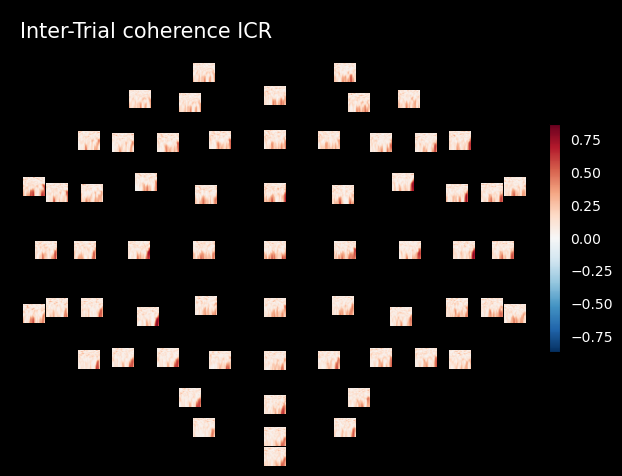

In [397]:
left_ave_itc.plot_topo(mode="logratio", title="Inter-Trial coherence ICL")
right_ave_itc.plot_topo(mode="logratio", title="Inter-Trial coherence ICR")

In [222]:
ch = "C3"
ch_in = itc.ch_names.index(ch)
left_ave_itc.plot(picks=[ch_in], mode="logratio", title=f"{itc.ch_names[ch_in]} ITC for ICL")
right_ave_itc.plot(picks=[ch_in], mode="logratio", title=f"{itc.ch_names[ch_in]} ITC for ICR")

[<Figure size 640x480 with 2 Axes>]

In [54]:
# Load correlation matries & Average across subjects (with Z-Trafo)
def load_correlation_matrices(fp, side, tmin, tmax):
    """Load all subject correlation matrices for a given time window and side."""
    
    corr_files = sorted([
        os.path.join(fp, f) for f in os.listdir(fp)
        if f.endswith('.xlsx') and f"_{side}" in f
    ])
    
    corr_matrices = []
    for f in corr_files:
        try:
            df = pd.read_excel(f, index_col=0)
            corr_matrices.append(df.values)
        except Exception as e:
            print(f"Failed to load {os.path.basename(f)}: {e}")
    
    if corr_matrices:
        corr_matrices = np.array(corr_matrices)  # Shape: (n_subjects, n_channels, n_channels)
        corr_matrices_clipped = np.clip(corr_matrices, -0.9999, 0.9999) # Edge cases (arctanh(1) = inf)
        z_matrices = np.arctanh(corr_matrices_clipped) # Z-Trafo
        mean_z_matrix = z_matrices.mean(axis=0)  # Shape: (n_channels, n_channels)
        #std_z_matrix = z_matrices.std(axis=0)
        group_mean_corr = np.tanh(mean_z_matrix) # Backtrafo
        #group_std_corr = np.tanh(std_z_matrix)

        return group_mean_corr
        #return group_mean_corr, group_std_corr
    else:
        return None

In [27]:
# Calculate and save individual correlations
# Single time window correlation (no Z-trafo)

side = "Right"
tmin = -0.25
tmax = -0.00

if side == "Left":
    epoch_list = epL  
else:
    epoch_list = epR  

μV = 1e6  
corr_matrices = []  


for subj_idx, epochs in enumerate(epoch_list):
    if epochs is None:
        continue
    
    try:
        epochs_crop = epochs.copy().pick("eeg").crop(tmin=tmin, tmax=tmax) # Cropping
        data = epochs_crop.get_data() * μV  # (n_epochs, n_channels, n_times)
        n_epochs, n_channels, n_times = data.shape
        
        epoch_matrices = np.zeros((n_epochs, n_channels, n_channels)) # Initiate corr_matrix for each epoch
        
        for i in range(n_epochs):
            epoch_data = data[i]  # (n_channels, n_times)
            corr_matrix = np.corrcoef(epoch_data)  # (n_channels, n_channels)
            epoch_matrices[i] = corr_matrix
                    
        # average epoch correlations       
        mean_corr_matrix = epoch_matrices.mean(axis=0)
        corr_matrices.append(mean_corr_matrix)
        
        print(f"Computed correlation matrix for subject {subj_idx}")
        
    except Exception as e:
        print(f"Skipping subject {subj_idx}: {e}")

# --- Output ---
print(f"\nTotal subjects processed: {len(corr_matrices)}")

# Save the results
for subj_idx, corr_matrix in enumerate(corr_matrices):
    try:
        df_corr = pd.DataFrame(
            corr_matrix,
            columns=epoch_list[subj_idx].pick("eeg").info['ch_names'],
            index=epoch_list[subj_idx].pick("eeg").info['ch_names']
        )
        filename = f"crossCorr_{tmin:.2f}to{tmax:.2f}_subject_{subj_idx+1}_{side}.xlsx"
        fp = wd + os.sep + "20250703_Epochs_AMICA85_wATR" + os.sep + f"CrossCorr_{tmin:.2f}to{tmax:.2f}"
        os.makedirs(fp, exist_ok=True)
        df_corr.to_excel(fp + os.sep + filename)
        #print(f"Saved mean corr matrix for subject {subj_idx+1} to {filename}")
    except Exception as e:
        print(f"Could not save subject {subj_idx+1}: {e}")


Computed correlation matrix for subject 0
Computed correlation matrix for subject 1
Computed correlation matrix for subject 2
Computed correlation matrix for subject 3
Computed correlation matrix for subject 4
Computed correlation matrix for subject 5
Computed correlation matrix for subject 6
Computed correlation matrix for subject 7
Computed correlation matrix for subject 8
Computed correlation matrix for subject 9
Computed correlation matrix for subject 10
Computed correlation matrix for subject 11
Computed correlation matrix for subject 12
Computed correlation matrix for subject 13
Computed correlation matrix for subject 14
Computed correlation matrix for subject 15
Computed correlation matrix for subject 16
Computed correlation matrix for subject 17
Computed correlation matrix for subject 18
Computed correlation matrix for subject 19
Computed correlation matrix for subject 20

Total subjects processed: 21


In [27]:
# Average across subjects & Corr-Matrix
side = "Right"
tmin = -0.25
tmax = -0.0

fp = os.path.join(wd, "20250703_Epochs_AMICA85_wATR", f"CrossCorr_{tmin:.2f}to{tmax:.2f}")

group_mean_corr = load_correlation_matrices(fp, side, tmin, tmax)

if group_mean_corr is not None and np.any(np.isfinite(group_mean_corr)):

    # --- Plot heatmap ---
    sns.set(style="white")
    plt.figure(figsize=(12, 10))
    ch_names = evL[0].ch_names
    ax = sns.heatmap(group_mean_corr, xticklabels=ch_names, yticklabels=ch_names,
                cmap='turbo', center=0, vmin=-1, vmax=1, annot=False, square=True,
                cbar_kws={"label": "Correlation Coefficient"})
    #plt.title(f" {side} Group-Averaged Pearson Correlation\nEvoked EEG({tmin*1000:.0f} to {tmax*1000:.0f} ms)", fontsize=18)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)  # Change tick label size
    cbar.set_label("Correlation Coefficient", fontsize=20)  # Change label size
    
    plt.title(f"IC_{side}", fontsize = 24)
    plt.tight_layout()
    plt.show()
else:
    print("No valid evoked data to compute correlation.")

In [25]:
# Plotting single topomaps

# Get channel index
ch = "C4"
ch_names = epL[0].pick("eeg").info['ch_names']
ch_index = ch_names.index(ch)

# Get values for channel from MI-matrix
ch_corr_values = group_mean_corr[ch_index, :] # shape: (n_channels,)
# set selected channel value to maximum value
ch_corr_values[ch_index] = np.max(ch_corr_values)
ch_corr_values = np.array(ch_corr_values)

# Create an MNE Info object with the correct montage
info = epL[0].info.copy()
layout = mne.channels.make_standard_montage('easycap-M1')
info.set_montage(layout)

# Plot topomap
fig, ax = plt.subplots(figsize=(12, 10))
im, _ = mne.viz.plot_topomap(
    ch_corr_values, info, axes=ax, names=ch_names, #show_names=True,
    cmap='turbo', contours=5
)
plt.title(f"{tmin*1000:.0f} ms to 0 ms for IC_{side} / {ch}", fontsize = 16)
#plt.title(f"Cross-Correlations (Pearson's R) for {ch} for {tmin} to {tmax*1000:.0f}s for IC_{side}")
plt.colorbar(im, ax=ax)
plt.show()

##### Extraction of Mean, Std, Min, Max

In [31]:
side = "Right"
tmin = -0.25
tmax = -0.0

In [29]:
fp = os.path.join(wd, "20250703_Epochs_AMICA85_wATR", f"CrossCorr_{tmin:.2f}to{tmax:.2f}")
    
corr_files = sorted([
    os.path.join(fp, f) for f in os.listdir(fp)
    if f.endswith('.xlsx') and f"_{side}" in f
])
    
corr_matrices = []
for f in corr_files:
    try:
        df = pd.read_excel(f, index_col=0)
        corr_matrices.append(df.values)
    except Exception as e:
        print(f"Failed to load {os.path.basename(f)}: {e}")
    
if corr_matrices:
    corr_matrices = np.array(corr_matrices)  # Shape: (n_subjects, n_channels, n_channels)
    corr_matrices_clipped = np.clip(corr_matrices, -0.9999, 0.9999) # Edge cases (arctanh(1) = inf)
    z_matrices = np.arctanh(corr_matrices_clipped) # Z-Trafo
    mean_z_matrix = z_matrices.mean(axis=0)  # Shape: (n_channels, n_channels)
    group_mean_corr = np.tanh(mean_z_matrix) # Backtrafo

    r_matrices = np.tanh(z_matrices)
    group_std_corr = r_matrices.std(axis=0, ddof=1) 


In [33]:
ch = "C4"
ch_names = epL[0].pick("eeg").info['ch_names']
ch_index = ch_names.index(ch)
ch_index

24

In [47]:
arti_chan = "Oz"
arti_chan_index = ch_names.index(arti_chan)
arti_chan_index

16

In [49]:
corr_max = np.max(corr_matrices, axis=0)[ch_index, arti_chan_index]
corr_min = np.min(corr_matrices, axis=0)[ch_index, arti_chan_index]
corr_mean = group_mean_corr[ch_index, arti_chan_index]
corr_std = group_std_corr[ch_index, arti_chan_index]

print(f"{corr_mean} +- {corr_std} ({corr_min} - {corr_max})")

-0.3319152819822474 +- 0.143010781678281 (-0.5852970477674229 - -0.1051782446237942)


In [93]:
# No Fisher Z-trafo (within subject)

side = "Left"
window_size = 0.05  # 50ms window
step_size = 0.05    # 50ms steps (non-overlapping)
start_time = -0.5   # Start at -500ms
end_time = 0        # End at stimulus onset

# Generate time windows
time_windows = []
tmin = start_time
while tmin + window_size <= end_time:
    tmax = tmin + window_size
    time_windows.append((tmin, tmax))
    tmin += step_size

print(f"Analyzing {len(time_windows)} time windows:")
for tw in time_windows:
    print(f"  {tw[0]:.2f}s to {tw[1]:.2f}s")


if side == "Left":
    epoch_list = epL  
else:
    epoch_list = epR

μV = 1e6

# Analyze each time window
for window_idx, (tmin, tmax) in enumerate(time_windows):
    print(f"\n{'='*20}")
    print(f"Processing time window {window_idx+1}/{len(time_windows)}: {tmin}s to {tmax}s")
    print(f"{'='*20}")
    
    corr_matrices = []  # Initalize corr_matrix for time window
    
    for subj_idx, epochs in enumerate(epoch_list):
        if epochs is None:
            continue
        
        try:
            epochs_crop = epochs.copy().pick("eeg").crop(tmin=tmin, tmax=tmax)
            
            data = epochs_crop.get_data() * μV  # (n_epochs, n_channels, n_times)
            n_epochs, n_channels, n_times = data.shape
            
            epoch_matrices = np.zeros((n_epochs, n_channels, n_channels)) # epoch-wse corr_matrix
            
            for i in range(n_epochs):
                epoch_data = data[i]  # (n_channels, n_times)
                
                corr_matrix = np.corrcoef(epoch_data)  # (n_channels, n_channels)
                epoch_matrices[i] = corr_matrix

            # Average in Z
            mean_corr_matrix = epoch_matrices.mean(axis=0)
            corr_matrices.append(mean_corr_matrix)
            
            print(f"  Subject {subj_idx+1}: Computed correlation matrix")
            
        except Exception as e:
            print(f"  Subject {subj_idx+1}: Skipping - {e}")
    
    # Save results
    print(f"\nSaving {len(corr_matrices)} correlation matrices for window {tmin}s to {tmax}s...")
    
    for subj_idx, corr_matrix in enumerate(corr_matrices):
        try:
            ch_names = epoch_list[subj_idx].pick("eeg").info['ch_names']
            
            df_corr = pd.DataFrame(
                corr_matrix,
                columns=ch_names,
                index=ch_names
            )
            
            filename = f"crossCorr_{tmin:.2f}to{tmax:.2f}_subject_{subj_idx+1}_{side}.xlsx"
            
            # Create output directory
            fp = wd + os.sep + "20250703_Epochs_AMICA85_wATR" + os.sep + f"CrossCorr_{tmin:.2f}to{tmax:.2f}"
            os.makedirs(fp, exist_ok=True)
            
            df_corr.to_excel(fp + os.sep + filename)

       
        except Exception as e:
            print(f"  Could not save subject {subj_idx+1}: {e}")
    
    print(f"Completed time window {tmin}s to {tmax}s")

print(f"\n{'='*60}")
print(f"ANALYSIS COMPLETE")
print(f"Processed {len(time_windows)} time windows")
print(f"Results saved to: {fp}")
print(f"{'='*60}")

Analyzing 10 time windows:
  -0.50s to -0.45s
  -0.45s to -0.40s
  -0.40s to -0.35s
  -0.35s to -0.30s
  -0.30s to -0.25s
  -0.25s to -0.20s
  -0.20s to -0.15s
  -0.15s to -0.10s
  -0.10s to -0.05s
  -0.05s to -0.00s

Processing time window 1/10: -0.5s to -0.45s
  Subject 1: Computed correlation matrix
  Subject 2: Computed correlation matrix
  Subject 3: Computed correlation matrix
  Subject 4: Computed correlation matrix
  Subject 5: Computed correlation matrix
  Subject 6: Computed correlation matrix
  Subject 7: Computed correlation matrix
  Subject 8: Computed correlation matrix
  Subject 9: Computed correlation matrix
  Subject 10: Computed correlation matrix
  Subject 11: Computed correlation matrix
  Subject 12: Computed correlation matrix
  Subject 13: Computed correlation matrix
  Subject 14: Computed correlation matrix
  Subject 15: Computed correlation matrix
  Subject 16: Computed correlation matrix
  Subject 17: Computed correlation matrix
  Subject 18: Computed correlati

In [94]:
# Plotting time course of Corr topomaps 

time_windows = [
    (-0.50, -0.45), (-0.45, -0.40), (-0.40, -0.35), (-0.35, -0.30), (-0.30, -0.25),
    (-0.25, -0.20), (-0.20, -0.15), (-0.15, -0.10), (-0.10, -0.05), (-0.05, -0.00)
]
channels_of_interest = ['C3', 'C4']
sides = ['Left', 'Right']

# Get channel info from your epochs (assumes epL/epR are available)
info = epL[0].info.copy()
layout = mne.channels.make_standard_montage('easycap-M1')
info.set_montage(layout)
ch_names = epL[0].pick("eeg").info['ch_names']


# Initiate grid
n_rows = len(sides) * len(channels_of_interest)  # 4 rows: L-C3, L-C4, R-C3, R-C4
n_cols = len(time_windows)  # 10 columns: time windows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10))
fig.suptitle('Channel-correlation Topomaps', 
             fontsize=20, fontweight='bold', y=0.95)

# Color scale limits (consistent across all topomaps)
vmin, vmax = -1, 1

# Row labels
row_labels = []
for side in sides:
    for ch in channels_of_interest:
        row_labels.append(f"{ch}")


# Generate Topomaps
for row_idx, side in enumerate(sides):
    for ch_idx, channel in enumerate(channels_of_interest):
        current_row = row_idx * len(channels_of_interest) + ch_idx
        
        # Get channel index
        ch_index = ch_names.index(channel)
        
        for col_idx, (tmin, tmax) in enumerate(time_windows):
            ax = axes[current_row, col_idx]
            
            # Load group-averaged correlation matrix for this time window
            group_mean_corr = load_correlation_matrices(side, tmin, tmax)
            
            if group_mean_corr is not None:
                # Extract correlation values for the selected channel
                ch_corr_values = group_mean_corr[ch_index, :].copy()
                
                # Set the channel's self-correlation to max for visualization
                ch_corr_values[ch_index] = np.max(ch_corr_values)
                
                # Plot topomap
                im, _ = mne.viz.plot_topomap(
                    ch_corr_values, 
                    info, 
                    axes=ax,
                    cmap='turbo', 
                    contours=6,
                    show=False
                )
                
                # Column titles (time windows) - only on top row
                if current_row == 0:
                    ax.set_title(f"{int(tmin*1000)} to\n{int(tmax*1000)} ms", 
                               fontsize=14, fontweight='bold', pad = 30)
                
                # Row labels (side + channel) - only on leftmost column
                if col_idx == 0:
                    ax.text(-0.3, 0.5, row_labels[current_row], 
                           transform=ax.transAxes,
                           fontsize=14, fontweight='bold',
                           verticalalignment='center',
                           horizontalalignment='right')
            else:
                ax.text(0.5, 0.5, 'No Data', 
                       transform=ax.transAxes,
                       ha='center', va='center', fontsize=10)
                ax.axis('off')



# Create a colorbar axis on the right side
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='turbo', 
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Correlation Coefficient', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=16)


plt.tight_layout(rect=[0, 0, 0.9, 0.96])  # Leave space for colorbar and title
plt.show()

# Optional: Save figure
# plt.savefig(os.path.join(wd, 'correlation_topomaps_grid.png'), 
#             dpi=300, bbox_inches='tight')

In [198]:
# Calculate and save individual correlations
# Single time window correlation (no Z-trafo)

side = "Left"
tmin = -0.25
tmax = -0.00

if side == "Left":
    epoch_list = epL  
else:
    epoch_list = epR  

μV = 1e6  
corr_matrices = []  


for subj_idx, epochs in enumerate(epoch_list):
    if epochs is None:
        continue
    
    try:
        epochs_crop = epochs.copy().crop(tmin=tmin, tmax=tmax) # Cropping
        data = epochs_crop.get_data() * μV  # (n_epochs, n_channels, n_times)
        n_epochs, n_channels, n_times = data.shape
        
        epoch_matrices = np.zeros((n_epochs, n_channels, n_channels)) # Initiate corr_matrix for each epoch
        
        for i in range(n_epochs):
            epoch_data = data[i]  # (n_channels, n_times)
            corr_matrix = np.corrcoef(epoch_data)  # (n_channels, n_channels)
            epoch_matrices[i] = corr_matrix
                    
        # average epoch correlations       
        mean_corr_matrix = epoch_matrices.mean(axis=0)
        corr_matrices.append(mean_corr_matrix)
        
        print(f"Computed correlation matrix for subject {subj_idx}")
        
    except Exception as e:
        print(f"Skipping subject {subj_idx}: {e}")

# --- Output ---
print(f"\nTotal subjects processed: {len(corr_matrices)}")

# Save the results
for subj_idx, corr_matrix in enumerate(corr_matrices):
    try:
        df_corr = pd.DataFrame(
            corr_matrix,
            columns=epoch_list[subj_idx].info['ch_names'],
            index=epoch_list[subj_idx].info['ch_names']
        )
        filename = f"crossCorr_{tmin:.2f}to{tmax:.2f}_subject_{subj_idx+1}_{side}.xlsx"
        fp = wd + os.sep + "20251215_EOG_corr" + os.sep + f"CrossCorr_{tmin:.2f}to{tmax:.2f}"
        os.makedirs(fp, exist_ok=True)
        df_corr.to_excel(fp + os.sep + filename)
        #print(f"Saved mean corr matrix for subject {subj_idx+1} to {filename}")
    except Exception as e:
        print(f"Could not save subject {subj_idx+1}: {e}")


Computed correlation matrix for subject 0
Computed correlation matrix for subject 1
Computed correlation matrix for subject 2
Computed correlation matrix for subject 3
Computed correlation matrix for subject 4
Computed correlation matrix for subject 5
Computed correlation matrix for subject 6
Computed correlation matrix for subject 7
Computed correlation matrix for subject 8
Computed correlation matrix for subject 9
Computed correlation matrix for subject 10
Computed correlation matrix for subject 11
Computed correlation matrix for subject 12
Computed correlation matrix for subject 13
Computed correlation matrix for subject 14
Computed correlation matrix for subject 15
Computed correlation matrix for subject 16
Computed correlation matrix for subject 17
Computed correlation matrix for subject 18
Computed correlation matrix for subject 19
Computed correlation matrix for subject 20

Total subjects processed: 21


In [200]:
# Load correlation matries & Average across subjects (with Z-Trafo)
def load_correlation_matrices(fp, side, tmin, tmax):
    """Load all subject correlation matrices for a given time window and side."""
    
    corr_files = sorted([
        os.path.join(fp, f) for f in os.listdir(fp)
        if f.endswith('.xlsx') and f"_{side}" in f
    ])
    
    corr_matrices = []
    for f in corr_files:
        try:
            df = pd.read_excel(f, index_col=0)
            corr_matrices.append(df.values)
        except Exception as e:
            print(f"Failed to load {os.path.basename(f)}: {e}")
    
    if corr_matrices:
        corr_matrices = np.array(corr_matrices)  # Shape: (n_subjects, n_channels, n_channels)
        corr_matrices_clipped = np.clip(corr_matrices, -0.9999, 0.9999) # Edge cases (arctanh(1) = inf)
        z_matrices = np.arctanh(corr_matrices_clipped) # Z-Trafo
        mean_z_matrix = z_matrices.mean(axis=0)  # Shape: (n_channels, n_channels)
        #std_z_matrix = z_matrices.std(axis=0)
        group_mean_corr = np.tanh(mean_z_matrix) # Backtrafo
        #group_std_corr = np.tanh(std_z_matrix)

        return group_mean_corr
        #return group_mean_corr, group_std_corr
    else:
        return None

In [227]:
# Average across subjects & Corr-Matrix
side = "Left"
tmin = -0.25
tmax = -0.0

fp = os.path.join(wd, "20251215_EOG_corr", f"CrossCorr_{tmin:.2f}to{tmax:.2f}")

group_mean_corr = load_correlation_matrices(fp, side, tmin, tmax)

if group_mean_corr is not None and np.any(np.isfinite(group_mean_corr)):

    # --- Plot heatmap ---
    sns.set(style="white")
    plt.figure(figsize=(12, 10))
    ch_names = evL[0].ch_names
    ax = sns.heatmap(group_mean_corr, xticklabels=ch_names, yticklabels=ch_names,
                cmap='turbo', center=0, vmin=-1, vmax=1, annot=False, square=True,
                cbar_kws={"label": "Correlation Coefficient"})
    #plt.title(f" {side} Group-Averaged Pearson Correlation\nEvoked EEG({tmin*1000:.0f} to {tmax*1000:.0f} ms)", fontsize=18)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)  # Change tick label size
    cbar.set_label("Correlation Coefficient", fontsize=20)  # Change label size
    
    plt.title(f"IC_{side}", fontsize = 24)
    plt.tight_layout()
    plt.show()
else:
    print("No valid evoked data to compute correlation.")

In [231]:
# Plotting single topomaps

# Get channel index
ch = "HEOG"
ch_names = epL[0].info['ch_names']
ch_index = ch_names.index(ch)

# Get values for channel from MI-matrix
ch_corr_values_all = group_mean_corr[ch_index, :] # shape: (n_channels (65),)

# EEG channels for corr plotting
eeg_ch_names = epL[0].copy().pick("eeg").info['ch_names']
eeg_indices = [ch_names.index(ch) for ch in eeg_ch_names]
ch_corr_values = ch_corr_values_all[eeg_indices]  # shape: (63,)

info = mne.pick_info(epL[0].info.copy(), eeg_indices)
layout = mne.channels.make_standard_montage('easycap-M1')
info.set_montage(layout)

ch_plot = info['ch_names']
# Plot topomap
fig, ax = plt.subplots(figsize=(12, 10))
im, _ = mne.viz.plot_topomap(
    ch_corr_values, info, axes=ax, names=ch_plot, #show_names=True,
    cmap='turbo', contours=5, vlim = (-1,1)
)
plt.title(f"{tmin*1000:.0f} ms to 0 ms for {side} trials / {ch}", fontsize = 16)
#plt.title(f"Cross-Correlations (Pearson's R) for {ch} for {tmin} to {tmax*1000:.0f}s for IC_{side}")
plt.colorbar(im, ax=ax)
plt.show()

#### Resampling

In [32]:
def resampleOddEven(epochs, iterations, trialNumbers, saveFolder):
    print(f'Working on {epochs.filename.name.split(".")[0]} -------------')
    ee = epochs.copy().pick(mne.pick_types(epochs.info, eeg=True))
    
    for sampleSize in trialNumbers:
        if sampleSize % 2 != 0: # Prune if sampleSize odd
            sampleSize -= 1
            
        print(f'Current sample size = {sampleSize}')
        S = datetime.now()
        
        odd_erps = []
        even_erps = []
        
        for ii in range(iterations):
            print('#', end='')
            idx = np.random.choice(len(ee), size=sampleSize, replace=True)
            eeSel = ee[idx]
            
            # Split the sample in half (since randomly chosen, odd/even is unnecessary - take halves instead)
            half = sampleSize // 2
            odd_erps.append(eeSel[:half].average())
            even_erps.append(eeSel[half:].average())

        print(f' | time elapsed: {(datetime.now()-S).seconds} seconds')
             
        # Save 100 permutation as epochs
        fname_odd = os.path.join(saveFolder, f"{epochs.filename.name.split('.')[0]}_{sampleSize}_ODD.fif")
        fname_even = os.path.join(saveFolder, f"{epochs.filename.name.split('.')[0]}_{sampleSize}_EVEN.fif")
        
        mne.write_evokeds(fname_odd, odd_erps, overwrite=True)
        mne.write_evokeds(fname_even, even_erps, overwrite=True)

In [34]:
resample_dir = os.path.join(wd, "20251129_SensorTrialsResampled")
os.makedirs(resample_dir, exist_ok=True)

for ep in epL:
    resampleOddEven(ep, 500, np.arange(10,71,10), resample_dir)

for ep in epR:
    resampleOddEven(ep, 500, np.arange(10,71,10), resample_dir)

Working on A37_IC_left_epochs_amica -------------
Current sample size = 10
#################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################### | time elapsed: 34 seconds
Current sample size = 20
####################################################################################################################################################################################################################################################################################################################################################################################

#### SNR calculation

##### Averaging odd and even trials
A specific way of obtaining replicates is to average all the odd and even trials in separate buffers. This has the advantage of allowing for comparison of even and odd results from interleaved trials. An average of odd and even averages generates the completed averaged result, while the difference between the odd and even averages, divided by two, constitutes an estimate of the noise (https://en.wikipedia.org/wiki/Signal_averaging). 


In [288]:
def getSNR(directory, condition, window, trial_num = None, verbose = True):
    fODD = []
    fEVEN = []
    fnames = os.listdir(directory)

    if trial_num is not None:
        if isinstance(trial_num, (int, np.integer)):
            trial_num_list = [trial_num]
        else:
            trial_num_list = list(trial_num)
    else:
        trial_num_list = None
    
    for f in fnames:
        if condition in f:
            # Extract trial number from filename
            try:
                f_trial_num = int(f.split("_")[-2])
            except (ValueError, IndexError):
                continue  # Skip files that don't have proper trial number format
            
            # Filter by trial_num if specified
            if trial_num_list is not None and f_trial_num not in trial_num_list:
                continue
            
            if 'ODD' in f:
                fODD.append(f)
            if 'EVEN' in f:
                fEVEN.append(f)

    snr_by_trials = {}
    for fo,fe in zip(fODD,fEVEN):
        if verbose:
            print('#',end='')
  
        #subj = fo.split('_')[0]
        f_trial_num = int(fo.split("_")[-2])
        
        dataSensorsODD  = mne.read_evokeds(os.path.join(directory, fo))
        dataSensorsEVEN = mne.read_evokeds(os.path.join(directory, fe))

        snrAll = []
        for o,e in zip(dataSensorsODD,dataSensorsEVEN):
            s = np.abs(np.mean([np.mean(o.copy().get_data(tmin=window[0],tmax=window[1]),axis = 1),
                np.mean(e.copy().get_data(tmin=window[0],tmax=window[1]),axis = 1)],axis = 0))
            n = np.abs(np.mean(o.copy().get_data(tmin=window[0],tmax=window[1]),axis = 1) - \
                np.mean(e.copy().get_data(tmin=window[0],tmax=window[1]),axis = 1))
            n = np.maximum(n, 0.01 * s)
            #snrAll.append(20*np.log10(s / n))
            snrAll.append(s/n)
        
        snr_ave = np.mean(np.array(snrAll),axis = 0) # Average SNR for 100 permutations


        # Store by trial number
        if f_trial_num not in snr_by_trials:
            snr_by_trials[f_trial_num] = []
        snr_by_trials[f_trial_num].append(snr_ave)
       
    if verbose:
        print(' done!')
    
    return snr_by_trials    

In [296]:
trial_num = np.arange(10,71,10)

resample_dir = os.path.join(wd, "20251129_SensorTrialsResampled")
#windowL = [-0.1, 0]
#windowR = [-0.1, 0]
windowL = [-0.31, -0.21]
windowR = [-0.322, -0.222]

snrL = getSNR(resample_dir, "left", windowL, trial_num = trial_num, verbose = True)
snrR = getSNR(resample_dir, "right", windowR, trial_num = trial_num, verbose = True)

################################################################################################################################################### done!
################################################################################################################################################### done!


In [297]:
# Save snr by trials values
snr_dir = os.path.join(wd, "20251129_SNR")
os.makedirs(snr_dir, exist_ok=True)

fL = f'snrL_trials_{int(windowL[0]*1000)}to{int(windowL[1]*1000)}ms.pkl'
fR = f'snrR_trials_{int(windowR[0]*1000)}to{int(windowR[1]*1000)}ms.pkl'

# Save as pickle file
with open(os.path.join(snr_dir, fL), 'wb') as f:
    pickle.dump(snrL, f)

with open(os.path.join(snr_dir, fR), 'wb') as f:
    pickle.dump(snrR, f)

print(f"SNR data saved to {snr_dir}")

SNR data saved to C:\Users\joelg\Seafile\Promotion\Erhebung_PoC\Daten_Messungen\EEG_Processing\PoC\20251129_SNR


In [34]:
#windowL = [-0.1, 0]
#windowR = [-0.1, 0]
windowL = [-0.31, -0.21]
windowR = [-0.322, -0.222]

snr_dir = os.path.join(wd, "20251129_SNR")
fL = f'snrL_trials_{int(windowL[0]*1000)}to{int(windowL[1]*1000)}ms.pkl'
fR = f'snrR_trials_{int(windowR[0]*1000)}to{int(windowR[1]*1000)}ms.pkl'

with open(os.path.join(snr_dir, fL), 'rb') as f:
    snrL = pickle.load(f)

with open(os.path.join(snr_dir, fR), 'rb') as f:
    snrR = pickle.load(f)

print(f"SNR ({fL} & {fR}) \n data loaded successfully!")

SNR (snrL_trials_-310to-210ms.pkl & snrR_trials_-322to-222ms.pkl) 
 data loaded successfully!


##### Violin plots

In [39]:
# Prepare data for plotting
trial_nums = np.arange(10, 71, 10)
side = "left"
channels = ['C3', 'C4']  # Both channels

# Extract SNR data
if side == "left":
    snr = snrL
    window = windowL
else:
    snr = snrR
    window = windowR

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 7))
fig.suptitle(f'SNR vs. Trial Counts - {side.capitalize()} in {int(window[0]*1000)} to {int(window[1]*1000)} ms', 
             fontsize=18, fontweight='bold')

for ax_idx, ch in enumerate(channels):
    ax = axes[ax_idx]
    ch_idx = epL[0].pick("eeg").info['ch_names'].index(ch)
    
    # Prepare data for this channel
    plot_data = []
    plot_positions = []
    mean_values = []
    
    for trial_num in trial_nums:
        if trial_num in snr:
            # Get all permutation SNR values for this trial number and channel
            snr_values = 20*np.log10([snr_data[ch_idx] for snr_data in snr[trial_num]])
            plot_data.append(snr_values)
            plot_positions.append(trial_num)
            mean_values.append(np.mean(snr_values))
    
    # Create violin plot
    parts = ax.violinplot(plot_data, positions=plot_positions, widths=4,
                          showmeans=False, showmedians=True, showextrema=False)
    
    # Style the violins
    for pc in parts['bodies']:
        pc.set_facecolor('#2E86AB')
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(2)
    
    # Add individual dots, median, and IQR for each violin
    for i, (trial_num, data) in enumerate(zip(plot_positions, plot_data)):
        data_array = np.array(data)
        
        # Add individual dots (with jitter for visibility)
        jitter = np.random.normal(0, 0.5, size=len(data_array))
        ax.scatter(trial_num + jitter, data_array, 
                  alpha=0.4, s=20, color='black', zorder=3)
        
        # Calculate statistics
        median = np.median(data_array)
        q25 = np.percentile(data_array, 25)
        q75 = np.percentile(data_array, 75)
        
        # Draw median line (thicker)
        ax.hlines(median, trial_num - 2, trial_num + 2, 
                  color='grey', linewidth=3, zorder=4, 
                  label='Median' if i == 0 else '')
        
        # Draw IQR lines (thinner)
        ax.hlines(q25, trial_num - 1.5, trial_num + 1.5, 
                 color='silver', linewidth=2, zorder=4, 
                 label='IQR' if i == 0 else '')
        ax.hlines(q75, trial_num - 1.5, trial_num + 1.5, 
                 color='silver', linewidth=2, zorder=4)
    
    # Add mean curve
    ax.plot(plot_positions, mean_values, 
            color='blueviolet', linewidth=4, marker='o', markersize=10,
            zorder=5, label='Mean', linestyle='-', alpha=0.7)
    # set y-axis
    ax.set_ylim(0, 33)
    
    # Styling
    ax.set_xlabel('Number of Trials', fontsize=14, fontweight='bold')
    ax.set_ylabel('SNR (dB)', fontsize=14, fontweight='bold')
    ax.set_title(f'Channel {ch}', fontsize=16, fontweight='bold')
    ax.set_xticks(plot_positions)
    ax.set_xticklabels(plot_positions, rotation=45)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Only show legend on first subplot
    #if ax_idx == 0:
    ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Optional: Save figure
# plt.savefig(os.path.join(wd, f'snr_violin_plot_{side}.png'), 
#             dpi=300, bbox_inches='tight')

In [41]:
# Plotting SNR topomaps for different trial numbers
trial_nums = [10, 20, 30, 40, 50, 60, 70]  # Trial numbers
sides_data = {'Left': snrL, 'Right': snrR}
sides = ['Left', 'Right']

# Get channel info from your epochs
info = epL[0].info.copy()
layout = mne.channels.make_standard_montage('easycap-M1')
info.set_montage(layout)

# Initiate grid
n_rows = len(sides)  # 2 rows: Left and Right
n_cols = len(trial_nums)  # 7 columns: trial numbers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8))
fig.suptitle(f'SNR Topomaps for Left: {int(windowL[0]*1000)} to {int(windowL[1]*1000)} ms and Right: {int(windowR[0]*1000)} to {int(windowR[1]*1000)} ms', 
             fontsize=20, fontweight='bold', y=0.98)

# ============================================================================
# First pass: determine vmin and vmax across all data (in dB)
all_snr_values = []
for side in sides:
    snr_data = sides_data[side]
    for trial_num in trial_nums:
        if trial_num in snr_data:
            # Average across all permutations, then convert to dB
            snr_array = np.array(snr_data[trial_num])  # Shape: (n_permutations, n_channels)
            mean_snr = np.mean(snr_array, axis=0)  # Mean across permutations
            snr_db = 20 * np.log10(mean_snr)
            all_snr_values.extend(snr_db.flatten())

vmin = 11 #np.percentile(all_snr_values, 0)   # Min
vmax = 23 #np.percentile(all_snr_values, 100)  # Max
# ============================================================================

# Generate Topomaps
for row_idx, side in enumerate(sides):
    snr_data = sides_data[side]
    
    for col_idx, trial_num in enumerate(trial_nums):
        ax = axes[row_idx, col_idx]
        
        if trial_num in snr_data:
            # ================================================================
            # Get SNR values for this trial number
            # snr_data[trial_num] is a list of arrays (one per permutation)
            snr_array = np.array(snr_data[trial_num])  # Shape: (n_permutations, n_channels)
            mean_snr = np.mean(snr_array, axis=0)  # Mean across permutations
            snr_values = 20 * np.log10(mean_snr)  # Convert to dB
            # ================================================================
            
            # Plot topomap
            im, _ = mne.viz.plot_topomap(
                snr_values, 
                info, 
                axes=ax,
                cmap='viridis',  # Good for SNR (sequential data)
                contours=6,
                vlim=(vmin, vmax),
                show=False
            )
            
            # Column titles (trial numbers) - only on top row
            if row_idx == 0:
                ax.set_title(f"{trial_num} trials", 
                           fontsize=14, fontweight='bold', pad=15)
            
            # Row labels (side) - only on leftmost column
            if col_idx == 0:
                ax.text(-0.3, 0.5, side, 
                       transform=ax.transAxes,
                       fontsize=14, fontweight='bold',
                       verticalalignment='center',
                       horizontalalignment='right')
        else:
            ax.text(0.5, 0.5, 'No Data', 
                   transform=ax.transAxes,
                   ha='center', va='center', fontsize=10)
            ax.axis('off')

# Create a colorbar axis on the right side
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.65])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='viridis', 
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('SNR (dB)', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

# Optional: Save figure
# plt.savefig(os.path.join(wd, 'snr_topomaps_trials.png'), 
#             dpi=300, bbox_inches='tight')

In [45]:
# Prepare data for table
trial_nums = [10, 20, 30, 40, 50, 60, 70]
side = "left"  # or "right"
channels = ['C3', 'C4']

# Select data based on side
if side == "left":
    snr = snrL
    window = windowL
else:
    snr = snrR
    window = windowR

# Get channel indices
ch_indices = {ch: epL[0].pick("eeg").info['ch_names'].index(ch) for ch in channels}

# Create data dictionary for DataFrame
table_data = {}

for ch in channels:
    ch_idx = ch_indices[ch]
    snr_values = []
    
    for trial_num in trial_nums:
        if trial_num in snr:
            # Get all permutation SNR values for this trial number and channel
            snr_array = np.array([snr_data[ch_idx] for snr_data in snr[trial_num]])
            # Convert to dB and take mean
            mean_snr_db = np.mean(20 * np.log10(snr_array))
            snr_values.append(f"{mean_snr_db:.2f}")
        else:
            snr_values.append("N/A")
    
    table_data[ch] = snr_values

# Create DataFrame
df = pd.DataFrame(table_data, index=trial_nums)
df.index.name = 'Trial Count'

# Display table
print(f"\nSNR (dB) for {side.capitalize()} - Window: {int(window[0]*1000)} to {int(window[1]*1000)} ms")
print("="*50)
print(df)


SNR (dB) for Left - Window: -310 to -210 ms
                C3     C4
Trial Count              
10           11.44  12.15
20           12.77  14.01
30           13.98  15.37
40           14.48  16.02
50           15.11  16.77
60           15.29  17.21
70           15.88  17.74


In [25]:
#1
cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
os.makedirs(cronbach_dir, exist_ok=True)

permutations = 500
side = "left"
electrode = 'C3'

if side == "left":
    e = epL
else:
    e = epR

plt.figure()

for trials in range(10,71,10):

    # Check if file already exists
    output_filename = f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"
    output_path = os.path.join(cronbach_dir, output_filename)
    
    if os.path.exists(output_path):
        print(f"File {output_filename} already exists - loading from disk")
        mean_alpha = np.load(output_path)
        plt.plot(mean_alpha, label=f'{trials} trials')
        continue  # Skip to next trial count

    allAlpha = []
    for perm in range(permutations):
        print(f'{trials} trials - repetition {perm+1} ',end='')
        allRandom = []
        for jj in range(len(e)):
            print('#',end='')
            for ii in range(trials):
                if ii < 1:
                    randTrials = np.array(e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode))
                else:
                    randTrials = np.concatenate([randTrials,e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode)])

            allRandom.append(np.squeeze(randTrials))

        X = np.array(allRandom)

        alphaTC = []
        for ii in range(X.shape[-1]):
            alphaTC.append(pingouin.cronbach_alpha(data = pd.DataFrame(np.squeeze(X[:,:,ii])))[0])

        allAlpha.append(alphaTC)
        print('@')
        
    print(f'Saving results from {permutations} permutations to cronbachAlpha_{electrode}_{trials}trials.npy')
    mean_alpha = np.mean(np.array(allAlpha),axis=0)
    np.save(os.path.join(cronbach_dir, f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"), mean_alpha)
    plt.plot(np.mean(np.array(allAlpha),axis=0),label = f'{trials} trials')
plt.legend()

File cronbachAlpha_500perm_left_C3_10trials.npy already exists - loading from disk
File cronbachAlpha_500perm_left_C3_20trials.npy already exists - loading from disk
File cronbachAlpha_500perm_left_C3_30trials.npy already exists - loading from disk
40 trials - repetition 1 #####################@
40 trials - repetition 2 #####################@
40 trials - repetition 3 #####################@
40 trials - repetition 4 #####################@
40 trials - repetition 5 #####################@
40 trials - repetition 6 #####################@
40 trials - repetition 7 #####################@
40 trials - repetition 8 #####################@
40 trials - repetition 9 #####################@
40 trials - repetition 10 #####################@
40 trials - repetition 11 #####################@
40 trials - repetition 12 #####################@
40 trials - repetition 13 #####################@
40 trials - repetition 14 #####################@
40 trials - repetition 15 #####################@
40 trials - repetition 16

In [26]:
#2
cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
os.makedirs(cronbach_dir, exist_ok=True)

permutations = 500
side = "left"
electrode = 'C4'

if side == "left":
    e = epL
else:
    e = epR

plt.figure()

for trials in range(10,71,10):
    
    # Check if file already exists
    output_filename = f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"
    output_path = os.path.join(cronbach_dir, output_filename)
    
    if os.path.exists(output_path):
        print(f"File {output_filename} already exists - loading from disk")
        mean_alpha = np.load(output_path)
        plt.plot(mean_alpha, label=f'{trials} trials')
        continue  # Skip to next trial count

    
    allAlpha = []
    for perm in range(permutations):
        print(f'{trials} trials - repetition {perm+1} ',end='')
        allRandom = []
        for jj in range(len(e)):
            print('#',end='')
            for ii in range(trials):
                if ii < 1:
                    randTrials = np.array(e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode))
                else:
                    randTrials = np.concatenate([randTrials,e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode)])

            allRandom.append(np.squeeze(randTrials))

        X = np.array(allRandom)

        alphaTC = []
        for ii in range(X.shape[-1]):
            alphaTC.append(pingouin.cronbach_alpha(data = pd.DataFrame(np.squeeze(X[:,:,ii])))[0])

        allAlpha.append(alphaTC)
        print('@')
        
    print(f'Saving results from {permutations} permutations to cronbachAlpha_{electrode}_{trials}trials.npy')
    mean_alpha = np.mean(np.array(allAlpha),axis=0)
    np.save(os.path.join(cronbach_dir, f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"), mean_alpha)
    plt.plot(np.mean(np.array(allAlpha),axis=0),label = f'{trials} trials')
plt.legend()

10 trials - repetition 1 #####################@
10 trials - repetition 2 #####################@
10 trials - repetition 3 #####################@
10 trials - repetition 4 #####################@
10 trials - repetition 5 #####################@
10 trials - repetition 6 #####################@
10 trials - repetition 7 #####################@
10 trials - repetition 8 #####################@
10 trials - repetition 9 #####################@
10 trials - repetition 10 #####################@
10 trials - repetition 11 #####################@
10 trials - repetition 12 #####################@
10 trials - repetition 13 #####################@
10 trials - repetition 14 #####################@
10 trials - repetition 15 #####################@
10 trials - repetition 16 #####################@
10 trials - repetition 17 #####################@
10 trials - repetition 18 #####################@
10 trials - repetition 19 #####################@
10 trials - repetition 20 #####################@
10 trials - repetition 21 ###

In [27]:
#3
cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
os.makedirs(cronbach_dir, exist_ok=True)

permutations = 500
side = "right"
electrode = 'C4'

if side == "left":
    e = epL
else:
    e = epR

plt.figure()

for trials in range(10,71,10):
    
    # Check if file already exists
    output_filename = f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"
    output_path = os.path.join(cronbach_dir, output_filename)
    
    if os.path.exists(output_path):
        print(f"File {output_filename} already exists - loading from disk")
        mean_alpha = np.load(output_path)
        plt.plot(mean_alpha, label=f'{trials} trials')
        continue  # Skip to next trial count

    
    allAlpha = []
    for perm in range(permutations):
        print(f'{trials} trials - repetition {perm+1} ',end='')
        allRandom = []
        for jj in range(len(e)):
            print('#',end='')
            for ii in range(trials):
                if ii < 1:
                    randTrials = np.array(e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode))
                else:
                    randTrials = np.concatenate([randTrials,e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode)])

            allRandom.append(np.squeeze(randTrials))

        X = np.array(allRandom)

        alphaTC = []
        for ii in range(X.shape[-1]):
            alphaTC.append(pingouin.cronbach_alpha(data = pd.DataFrame(np.squeeze(X[:,:,ii])))[0])

        allAlpha.append(alphaTC)
        print('@')
        
    print(f'Saving results from {permutations} permutations to cronbachAlpha_{electrode}_{trials}trials.npy')
    mean_alpha = np.mean(np.array(allAlpha),axis=0)
    np.save(os.path.join(cronbach_dir, f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"), mean_alpha)
    plt.plot(np.mean(np.array(allAlpha),axis=0),label = f'{trials} trials')
plt.legend()

10 trials - repetition 1 #####################@
10 trials - repetition 2 #####################@
10 trials - repetition 3 #####################@
10 trials - repetition 4 #####################@
10 trials - repetition 5 #####################@
10 trials - repetition 6 #####################@
10 trials - repetition 7 #####################@
10 trials - repetition 8 #####################@
10 trials - repetition 9 #####################@
10 trials - repetition 10 #####################@
10 trials - repetition 11 #####################@
10 trials - repetition 12 #####################@
10 trials - repetition 13 #####################@
10 trials - repetition 14 #####################@
10 trials - repetition 15 #####################@
10 trials - repetition 16 #####################@
10 trials - repetition 17 #####################@
10 trials - repetition 18 #####################@
10 trials - repetition 19 #####################@
10 trials - repetition 20 #####################@
10 trials - repetition 21 ###

In [28]:
#4
cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
os.makedirs(cronbach_dir, exist_ok=True)

permutations = 500
side = "right"
electrode = 'C3'

if side == "left":
    e = epL
else:
    e = epR

plt.figure()

for trials in range(10,71,10):
    
    # Check if file already exists
    output_filename = f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"
    output_path = os.path.join(cronbach_dir, output_filename)
    
    if os.path.exists(output_path):
        print(f"File {output_filename} already exists - loading from disk")
        mean_alpha = np.load(output_path)
        plt.plot(mean_alpha, label=f'{trials} trials')
        continue  # Skip to next trial count

    
    allAlpha = []
    for perm in range(permutations):
        print(f'{trials} trials - repetition {perm+1} ',end='')
        allRandom = []
        for jj in range(len(e)):
            print('#',end='')
            for ii in range(trials):
                if ii < 1:
                    randTrials = np.array(e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode))
                else:
                    randTrials = np.concatenate([randTrials,e[jj][randint(0,len(e[jj])-1)].get_data(picks=electrode)])

            allRandom.append(np.squeeze(randTrials))

        X = np.array(allRandom)

        alphaTC = []
        for ii in range(X.shape[-1]):
            alphaTC.append(pingouin.cronbach_alpha(data = pd.DataFrame(np.squeeze(X[:,:,ii])))[0])

        allAlpha.append(alphaTC)
        print('@')
        
    print(f'Saving results from {permutations} permutations to cronbachAlpha_{electrode}_{trials}trials.npy')
    mean_alpha = np.mean(np.array(allAlpha),axis=0)
    np.save(os.path.join(cronbach_dir, f"cronbachAlpha_{permutations}perm_{side}_{electrode}_{trials}trials.npy"), mean_alpha)
    plt.plot(np.mean(np.array(allAlpha),axis=0),label = f'{trials} trials')
plt.legend()

10 trials - repetition 1 #####################@
10 trials - repetition 2 #####################@
10 trials - repetition 3 #####################@
10 trials - repetition 4 #####################@
10 trials - repetition 5 #####################@
10 trials - repetition 6 #####################@
10 trials - repetition 7 #####################@
10 trials - repetition 8 #####################@
10 trials - repetition 9 #####################@
10 trials - repetition 10 #####################@
10 trials - repetition 11 #####################@
10 trials - repetition 12 #####################@
10 trials - repetition 13 #####################@
10 trials - repetition 14 #####################@
10 trials - repetition 15 #####################@
10 trials - repetition 16 #####################@
10 trials - repetition 17 #####################@
10 trials - repetition 18 #####################@
10 trials - repetition 19 #####################@
10 trials - repetition 20 #####################@
10 trials - repetition 21 ###

#### Plotting Alpha


In [15]:
# Load data
cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
permutations = 500
side = "left"  # "left" or "right"
channels = ['C3', 'C4']
trial_counts = [10, 20, 30, 40, 50, 60, 70]

# Get time vector from epochs (in seconds)
times = epL[0].times

# Get ATR (direction signal) times
def get_atr_stats(epochs):
    atrs = [np.mean(ep.metadata.values) for ep in epochs if ep.metadata is not None and not ep.metadata.empty]
    if not atrs:
        return None, None, None, None
    n = len(atrs)
    mean_atr = np.mean(atrs)
    std_atr = np.std(atrs, ddof=1)
    sem_atr = std_atr / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci95_atr = t_crit * sem_atr
    return mean_atr, std_atr, sem_atr, ci95_atr

mean_atr_l, std_atr_l, sem_atr_l, ci95_atr_l = get_atr_stats(epL)
mean_atr_r, std_atr_r, sem_atr_r, ci95_atr_r = get_atr_stats(epR)

# Convert to seconds (ATR is in ms, negative for time before stimulus)
direction_time_left = -mean_atr_l / 1000  # Convert ms to seconds
direction_time_right = -mean_atr_r / 1000
ci95_left = ci95_atr_l / 1000  # Convert CI to seconds
ci95_right = ci95_atr_r / 1000

# Load data for both channels
data = {ch: {} for ch in channels}

for ch in channels:
    for trials in trial_counts:
        filename = f"cronbachAlpha_{permutations}perm_{side}_{ch}_{trials}trials.npy"
        filepath = os.path.join(cronbach_dir, filename)
        
        if os.path.exists(filepath):
            data[ch][trials] = np.load(filepath)
            print(f"Loaded: {filename}")
        else:
            print(f"Missing: {filename}")

# Create figure with subplots for C3 and C4
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f"Cronbach's Alpha Time Course - {side.capitalize()}", 
             fontsize=18, fontweight='bold')

# Color map for different trial counts
colors_trials = plt.cm.viridis(np.linspace(0, 0.9, len(trial_counts)))
colors_side = {"left": "red", "right": "blue"}

for ax_idx, ch in enumerate(channels):
    ax = axes[ax_idx]
    
    for trial_idx, trials in enumerate(trial_counts):
        if trials in data[ch]:
            alpha_values = data[ch][trials]
            ax.plot(times, alpha_values, 
                   color=colors_trials[trial_idx], 
                   linewidth=2.5, 
                   label=f'{trials} trials',
                   alpha=0.8)
    
    # Vertical line at stimulus onset (t=0) - BLACK SOLID
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    # Direction signal with shaded 95% CI (based on side)
    if side == "left":
        direction_time = direction_time_left
        ci95_time = ci95_left
        mean_atr = mean_atr_l
        std_atr = std_atr_l
        color = colors_side["left"]
        linestyle = ':'
    else:
        direction_time = direction_time_right
        ci95_time = ci95_right
        mean_atr = mean_atr_r
        std_atr = std_atr_r
        color = colors_side["right"]
        linestyle = '-.'
    
    # Vertical line for direction signal
    ax.axvline(direction_time, color=color, linestyle=linestyle, 
               linewidth=1.5, alpha=0.6)
    
    # Shaded 95% CI region
    ax.axvspan(direction_time - ci95_time, direction_time + ci95_time, 
               color=color, alpha=0.15)
    
    # Horizontal dashed lines at 0.7 and 0.9
    ax.axhline(y=0.7, color='grey', linestyle='--', linewidth=1.5, 
               alpha=0.6, label='α = 0.7')
    ax.axhline(y=0.9, color='darkgrey', linestyle='--', linewidth=1.5, 
               alpha=0.6, label='α = 0.9')
    

    ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
    ax.set_ylabel("Cronbach's Alpha", fontsize=14, fontweight='bold')
    ax.set_title(f'Channel {ch}', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Create legend with trial counts
    legend1 = ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)
    
    # Add text box with direction signal timing (like in MRCP plot)
    textstr = f'ATR = {mean_atr:.1f} ± {std_atr:.1f} ms'
    props = dict(boxstyle='round', facecolor=color, alpha=0.3)
    ax.text(0.9, 0.02, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    ax.set_ylim([-0.05, 1.05])
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

Loaded: cronbachAlpha_500perm_left_C3_10trials.npy
Loaded: cronbachAlpha_500perm_left_C3_20trials.npy
Loaded: cronbachAlpha_500perm_left_C3_30trials.npy
Loaded: cronbachAlpha_500perm_left_C3_40trials.npy
Loaded: cronbachAlpha_500perm_left_C3_50trials.npy
Loaded: cronbachAlpha_500perm_left_C3_60trials.npy
Loaded: cronbachAlpha_500perm_left_C3_70trials.npy
Loaded: cronbachAlpha_500perm_left_C4_10trials.npy
Loaded: cronbachAlpha_500perm_left_C4_20trials.npy
Loaded: cronbachAlpha_500perm_left_C4_30trials.npy
Loaded: cronbachAlpha_500perm_left_C4_40trials.npy
Loaded: cronbachAlpha_500perm_left_C4_50trials.npy
Loaded: cronbachAlpha_500perm_left_C4_60trials.npy
Loaded: cronbachAlpha_500perm_left_C4_70trials.npy


#### Alpha: Thresholds

In [130]:
# calculate times where curve for k trials is above threshold (e.g. 0.9)



In [82]:
# ============================================================================
# PARAMETERS - SET THESE
trials = 70  # Number of trials to analyze
threshold = 0.9  # Alpha threshold
side = "right"  # "left" or "right"
min_duration = 0.05  # Minimum duration in seconds (e.g., 0.05 = 50 ms)
# ============================================================================

cronbach_dir = os.path.join(wd, "20251219_CronbachAlpha_500perm")
permutations = 500
channels = ['C3', 'C4']

# Get time vector from epochs (in seconds)
times = epL[0].times

# ============================================================================
# Get ATR (direction signal) times
def get_atr_stats(epochs):
    atrs = [np.mean(ep.metadata.values) for ep in epochs if ep.metadata is not None and not ep.metadata.empty]
    if not atrs:
        return None, None, None, None
    n = len(atrs)
    mean_atr = np.mean(atrs)
    std_atr = np.std(atrs, ddof=1)
    sem_atr = std_atr / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci95_atr = t_crit * sem_atr
    return mean_atr, std_atr, sem_atr, ci95_atr

mean_atr_l, std_atr_l, sem_atr_l, ci95_atr_l = get_atr_stats(epL)
mean_atr_r, std_atr_r, sem_atr_r, ci95_atr_r = get_atr_stats(epR)

# Convert to seconds (ATR is in ms, negative for time before stimulus)
direction_time_left = -mean_atr_l / 1000
direction_time_right = -mean_atr_r / 1000
ci95_left = ci95_atr_l / 1000
ci95_right = ci95_atr_r / 1000

# Select based on side
if side == "left":
    direction_time = direction_time_left
    ci95_time = ci95_left
    mean_atr = mean_atr_l
    std_atr = std_atr_l
    color_side = "red"
    linestyle_atr = ':'
else:
    direction_time = direction_time_right
    ci95_time = ci95_right
    mean_atr = mean_atr_r
    std_atr = std_atr_r
    color_side = "blue"
    linestyle_atr = '-.'
# ============================================================================

# Load data for specified trial count
results = {}

for ch in channels:
    filename = f"cronbachAlpha_{permutations}perm_{side}_{ch}_{trials}trials.npy"
    filepath = os.path.join(cronbach_dir, filename)
    
    if os.path.exists(filepath):
        alpha_values = np.load(filepath)
        
        # Find where alpha exceeds threshold
        above_threshold = alpha_values >= threshold
        
        # Get time points where threshold is exceeded
        time_points_above = times[above_threshold]
        
        # Find continuous segments
        # Detect transitions
        transitions = np.diff(above_threshold.astype(int))
        starts = np.where(transitions == 1)[0] + 1  # Going above threshold
        ends = np.where(transitions == -1)[0] + 1   # Going below threshold
        
        # Handle edge cases
        if above_threshold[0]:  # Starts above threshold
            starts = np.concatenate([[0], starts])
        if above_threshold[-1]:  # Ends above threshold
            ends = np.concatenate([ends, [len(above_threshold)]])
        
        # Filter segments by minimum duration
        all_segments = [(times[s], times[e-1]) for s, e in zip(starts, ends)]
        filtered_segments = [(start, end) for start, end in all_segments 
                            if (end - start) >= min_duration]
        
        # Create filtered above_threshold mask
        filtered_above_threshold = np.zeros_like(above_threshold, dtype=bool)
        for start_time, end_time in filtered_segments:
            mask = (times >= start_time) & (times <= end_time)
            filtered_above_threshold |= mask
        
        total_duration_filtered = np.sum(filtered_above_threshold) * np.diff(times)[0]
        
        # Store results
        results[ch] = {
            'alpha_values': alpha_values,
            'above_threshold': filtered_above_threshold,
            'time_points_above': times[filtered_above_threshold],
            'all_segments': all_segments,
            'segments': filtered_segments,
            'total_duration': total_duration_filtered,
            'first_crossing': filtered_segments[0][0] if len(filtered_segments) > 0 else None
        }
        
        print(f"\n{ch} - {trials} trials - Threshold α ≥ {threshold} - Min duration: {min_duration*1000:.0f} ms")
        print("=" * 70)
        print(f"Total segments found: {len(all_segments)}")
        print(f"Segments ≥ {min_duration*1000:.0f} ms: {len(filtered_segments)}")
        print(f"Total time above threshold (filtered): {results[ch]['total_duration']:.3f} s")
        print(f"First time crossing threshold: {results[ch]['first_crossing']:.3f} s" if results[ch]['first_crossing'] else "No segments meet criteria")
        
        if len(filtered_segments) > 0:
            print(f"\nTime segments where α ≥ {threshold} for ≥ {min_duration*1000:.0f} ms:")
            for i, (start, end) in enumerate(filtered_segments):
                duration = end - start
                print(f"  Segment {i+1}: {start:.3f} s to {end:.3f} s (duration: {duration*1000:.1f} ms)")
        
        # Show rejected segments if any
        rejected_segments = [(s, e) for s, e in all_segments if (e - s) < min_duration]
        if len(rejected_segments) > 0:
            print(f"\nRejected segments (< {min_duration*1000:.0f} ms):")
            for i, (start, end) in enumerate(rejected_segments):
                duration = end - start
                print(f"  Segment {i+1}: {start:.3f} s to {end:.3f} s (duration: {duration*1000:.1f} ms)")
    else:
        print(f"File not found: {filename}")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f"Cronbach's Alpha ≥ {threshold} for ≥ {min_duration*1000:.0f} ms - {trials} trials - {side.capitalize()}", 
             fontsize=18, fontweight='bold')

for ax_idx, ch in enumerate(channels):
    ax = axes[ax_idx]
    
    if ch in results:
        # Plot alpha time course
        ax.plot(times, results[ch]['alpha_values'], 
               color='#440154', linewidth=2.5, label=f"α (C{ch[1]})", alpha=0.85)
        
        # Highlight regions above threshold (filtered by min_duration)
        ax.fill_between(times, threshold, 1.0, 
                        where=results[ch]['above_threshold'],
                        color='green', alpha=0.3, label=f'α ≥ {threshold} (≥{min_duration*1000:.0f}ms)')
        
        # Threshold line
        ax.axhline(y=threshold, color='red', linestyle='--', 
                  linewidth=2, alpha=0.7, label=f'Threshold ({threshold})')
        
        # ====================================================================
        # Stimulus onset (t=0) - BLACK
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        
        # Direction signal (ATR) with shaded 95% CI
        ax.axvline(direction_time, color=color_side, linestyle=linestyle_atr, 
                   linewidth=1.5, alpha=0.6)
        ax.axvspan(direction_time - ci95_time, direction_time + ci95_time, 
                   color=color_side, alpha=0.15)
        # ====================================================================
        
        # Mark segment boundaries
        for start, end in results[ch]['segments']:
            ax.axvline(x=start, color='green', linestyle=':', linewidth=1, alpha=0.5)
            ax.axvline(x=end, color='red', linestyle=':', linewidth=1, alpha=0.5)
        
        # Styling
        ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
        ax.set_ylabel("Cronbach's Alpha", fontsize=14, fontweight='bold')
        ax.set_title(f'Channel {ch}', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)
        ax.set_ylim([0.5, 1.0])
        ax.tick_params(labelsize=12)
        
        # ====================================================================
        # Add text box with ATR timing
        textstr_atr = f'ATR = {mean_atr:.1f} ± {std_atr:.1f} ms'
        props_atr = dict(boxstyle='round', facecolor=color_side, alpha=0.3)
        ax.text(0.75, 0.02, textstr_atr, transform=ax.transAxes, fontsize=12,
                verticalalignment='bottom', horizontalalignment='right', bbox=props_atr)
        # ====================================================================
        
        # Add text box with alpha summary
        textstr = f'Above threshold:\n{results[ch]["total_duration"]:.3f} s total\n{len(results[ch]["segments"])} segments ≥ {min_duration*1000:.0f}ms'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print(f"SUMMARY: {side.capitalize()} - {trials} trials - α ≥ {threshold} - Min duration: {min_duration*1000:.0f} ms")
print("="*70)

for ch in channels:
    if ch in results:
        print(f"\n{ch}:")
        print(f"  First crossing: {results[ch]['first_crossing']:.3f} s" if results[ch]['first_crossing'] else "  No segments meet criteria")
        print(f"  Total duration: {results[ch]['total_duration']:.3f} s ({results[ch]['total_duration']*1000:.0f} ms)")
        print(f"  Number of segments: {len(results[ch]['segments'])}")


C3 - 70 trials - Threshold α ≥ 0.9 - Min duration: 50 ms
Total segments found: 3
Segments ≥ 50 ms: 3
Total time above threshold (filtered): 0.640 s
First time crossing threshold: -0.644 s

Time segments where α ≥ 0.9 for ≥ 50 ms:
  Segment 1: -0.644 s to -0.586 s (duration: 58.0 ms)
  Segment 2: -0.582 s to -0.484 s (duration: 98.0 ms)
  Segment 3: -0.478 s to 0.000 s (duration: 478.0 ms)

C4 - 70 trials - Threshold α ≥ 0.9 - Min duration: 50 ms
Total segments found: 5
Segments ≥ 50 ms: 4
Total time above threshold (filtered): 0.584 s
First time crossing threshold: -0.712 s

Time segments where α ≥ 0.9 for ≥ 50 ms:
  Segment 1: -0.712 s to -0.658 s (duration: 54.0 ms)
  Segment 2: -0.654 s to -0.442 s (duration: 212.0 ms)
  Segment 3: -0.324 s to -0.064 s (duration: 260.0 ms)
  Segment 4: -0.050 s to 0.000 s (duration: 50.0 ms)

Rejected segments (< 50 ms):
  Segment 1: -0.436 s to -0.426 s (duration: 10.0 ms)

SUMMARY: Right - 70 trials - α ≥ 0.9 - Min duration: 50 ms

C3:
  First cr

In [25]:
def plotBoxHist(x, xLabel, Title):
    sns.set(style="ticks")
    f, (axBox, axHist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    bp = sns.boxplot(x=x, ax=axBox, orient="h")
    hp = sns.histplot(x=x, ax=axHist)
    axBox.set(yticks=[])
    sns.despine(ax=axHist)
    sns.despine(ax=axBox, left=True)
    hp.set(xlabel=xLabel, ylabel= "Nr. of subjects")
    bp.set(title=Title)
    axBox.title.set_fontsize(16)
    plt.tight_layout()
    return f

# Your rejected trials data
rejected_total = [0, 0, -8, -14, -57, -13, -1, 0, -17, 0, -1, 0, 0, -2, -6, -46, -10, 0, 0, -50, 0]

# Create the plot
plotBoxHist(rejected_total, 'Rejected Trials', 'Rejected Trials due to EEG processing')
plt.show()

In [ ]:
def getSNRsensors(Ss, condition, window, verbose):
    fODD = []
    fEVEN = []
    fnames = os.listdir(wd + os.sep + '20251009_SensorTrialsResampled' + os.sep + Ss)
    for f in fnames:
        if condition in f:
            if 'ODD' in f:
                fODD.append(f)
            if 'EVEN' in f:
                fEVEN.append(f)
    fODD.sort()
    fEVEN.sort()

    snrAvg = []
    for fo,fe in zip(fODD,fEVEN):
        if verbose:
            print('#',end='')
        dataSensorsODD  = load(os.getcwd() + os.sep + 'SNRsensors' + os.sep + Ss + os.sep + fo)
        dataSensorsEVEN = load(os.getcwd() + os.sep + 'SNRsensors' + os.sep + Ss + os.sep + fe)

        snrAll = []
        snr = dataSensorsODD[0]
        for o,e in zip(dataSensorsODD,dataSensorsEVEN):
            s = np.mean([np.mean(np.abs(o.copy().get_data(tmin=window[0],tmax=window[1])),axis = 1),
                np.mean(np.abs(e.copy().get_data(tmin=window[0],tmax=window[1])),axis = 1)],axis = 0)
            n = np.abs([np.mean(np.abs(o.copy().get_data(tmin=window[0],tmax=window[1])),axis = 1) - \
                np.mean(np.abs(e.copy().get_data(tmin=window[0],tmax=window[1])),axis = 1)])
            snrAll.append(20*np.log10(np.divide(np.abs(s),np.abs(n))))
        
        snrAvg.append(np.mean(np.array(snrAll),axis = 0))
    if verbose:
        print(' done!')   

    return snrAvg   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mne.stats import spatio_temporal_cluster_test
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Run the test
X = [epL[0].get_data(), epR[0].get_data()]
t_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
    X, n_permutations=1000, tail=0, n_jobs=-1
)

# Get epochs info for plotting
epochs = epL[0]  # Use one condition for structure
times = epochs.times
ch_names = epochs.ch_names

# ============================================================================
# 1. OVERVIEW: T-values across all channels and time
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(t_obs, aspect='auto', origin='lower', cmap='RdBu_r',
               extent=[times[0], times[-1], 0, len(ch_names)],
               vmin=-np.max(np.abs(t_obs)), vmax=np.max(np.abs(t_obs)))
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Channel', fontsize=12)
ax.set_yticks(np.arange(0, len(ch_names), 5))
ax.set_yticklabels(ch_names[::5])
ax.set_title('T-values: Left vs Right condition', fontsize=14, fontweight='bold')
ax.axvline(0, color='k', linestyle='--', linewidth=1, label='Stimulus onset')
plt.colorbar(im, ax=ax, label='T-value')
plt.tight_layout()
plt.show()

# ============================================================================
# 2. SIGNIFICANT CLUSTERS: Mask overlay
# ============================================================================
# Create binary mask for significant clusters
sig_mask = np.zeros_like(t_obs, dtype=bool)
for i_cluster, cluster in enumerate(clusters):
    if cluster_p_values[i_cluster] < 0.05:
        sig_mask[cluster] = True

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: T-values
im1 = axes[0].imshow(t_obs, aspect='auto', origin='lower', cmap='RdBu_r',
                     extent=[times[0], times[-1], 0, len(ch_names)],
                     vmin=-np.max(np.abs(t_obs)), vmax=np.max(np.abs(t_obs)))
axes[0].set_ylabel('Channel', fontsize=12)
axes[0].set_title('T-values', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='k', linestyle='--', linewidth=1)
plt.colorbar(im1, ax=axes[0], label='T-value')

# Bottom: Significant clusters only
masked_t = np.ma.masked_where(~sig_mask, t_obs)
im2 = axes[1].imshow(masked_t, aspect='auto', origin='lower', cmap='RdBu_r',
                     extent=[times[0], times[-1], 0, len(ch_names)],
                     vmin=-np.max(np.abs(t_obs)), vmax=np.max(np.abs(t_obs)))
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('Channel', fontsize=12)
axes[1].set_title('Significant clusters (p < 0.05)', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
plt.colorbar(im2, ax=axes[1], label='T-value')

plt.tight_layout()
plt.show()

# ============================================================================
# 3. CLUSTER DETAILS: Individual clusters with statistics
# ============================================================================
print(f"\nFound {len(clusters)} clusters")
print(f"Significant clusters (p < 0.05): {np.sum(cluster_p_values < 0.05)}")

for i_cluster, (cluster, p_val) in enumerate(zip(clusters, cluster_p_values)):
    if p_val < 0.05:
        # Get cluster info
        ch_idx, time_idx = cluster
        ch_involved = np.unique(ch_idx)
        time_involved = times[np.unique(time_idx)]
        
        print(f"\n--- Cluster {i_cluster + 1} ---")
        print(f"p-value: {p_val:.4f}")
        print(f"Time range: {time_involved.min():.3f} - {time_involved.max():.3f} s")
        print(f"Number of channels: {len(ch_involved)}")
        print(f"Channels: {', '.join([ch_names[i] for i in ch_involved[:10]])}" + 
              ("..." if len(ch_involved) > 10 else ""))
        print(f"Max |t-value| in cluster: {np.abs(t_obs[cluster]).max():.2f}")

# ============================================================================
# 4. TOPOGRAPHIC MAPS: Significant time windows
# ============================================================================
# Find time windows with significant effects
sig_times_all = times[np.unique(np.where(sig_mask)[1])]

if len(sig_times_all) > 0:
    # Select representative time points (up to 6)
    if len(sig_times_all) > 6:
        time_indices = np.linspace(0, len(sig_times_all)-1, 6, dtype=int)
        plot_times = sig_times_all[time_indices]
    else:
        plot_times = sig_times_all[::max(1, len(sig_times_all)//6)]
    
    # Compute difference wave using mne.combine_evoked
    from mne import combine_evoked
    
    evoked_L = epL[0].average()
    evoked_R = epR[0].average()
    
    # Method 1: Using combine_evoked
    evoked_diff = combine_evoked([evoked_L, evoked_R], weights=[1, -1])
    
    # OR Method 2: Manual subtraction
    # evoked_diff = evoked_L.copy()
    # evoked_diff.data = evoked_L.data - evoked_R.data
    
    fig = evoked_diff.plot_topomap(times=plot_times, 
                                    ch_type='eeg',
                                    average=0.05,  # Average 50ms around each time point
                                    cmap='RdBu_r',
                                    size=3,
                                    time_unit='s')
    plt.show()
    
# ============================================================================
# 5. TIME COURSE: Average across significant channels
# ============================================================================
if np.any(sig_mask):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Get data for both conditions
    data_L = epL[0].get_data()  # trials × channels × time
    data_R = epR[0].get_data()
    
    # Average across trials
    mean_L = data_L.mean(axis=0)  # channels × time
    mean_R = data_R.mean(axis=0)
    sem_L = data_L.std(axis=0) / np.sqrt(data_L.shape[0])
    sem_R = data_R.std(axis=0) / np.sqrt(data_R.shape[0])
    
    # Top: Grand average across all channels
    axes[0].plot(times, mean_L.mean(axis=0), label='Left', linewidth=2, color='blue')
    axes[0].fill_between(times, 
                         mean_L.mean(axis=0) - sem_L.mean(axis=0),
                         mean_L.mean(axis=0) + sem_L.mean(axis=0),
                         alpha=0.3, color='blue')
    axes[0].plot(times, mean_R.mean(axis=0), label='Right', linewidth=2, color='red')
    axes[0].fill_between(times,
                         mean_R.mean(axis=0) - sem_R.mean(axis=0),
                         mean_R.mean(axis=0) + sem_R.mean(axis=0),
                         alpha=0.3, color='red')
    axes[0].axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    axes[0].set_ylabel('Amplitude (µV)', fontsize=12)
    axes[0].set_title('Grand average (all channels)', fontsize=12, fontweight='bold')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Bottom: Average only significant channels/timepoints
    # Find which channels are involved in significant clusters
    sig_channels = np.any(sig_mask, axis=1)
    
    if np.any(sig_channels):
        mean_L_sig = mean_L[sig_channels].mean(axis=0)
        mean_R_sig = mean_R[sig_channels].mean(axis=0)
        sem_L_sig = sem_L[sig_channels].mean(axis=0)
        sem_R_sig = sem_R[sig_channels].mean(axis=0)
        
        axes[1].plot(times, mean_L_sig, label='Left', linewidth=2, color='blue')
        axes[1].fill_between(times, mean_L_sig - sem_L_sig, mean_L_sig + sem_L_sig,
                           alpha=0.3, color='blue')
        axes[1].plot(times, mean_R_sig, label='Right', linewidth=2, color='red')
        axes[1].fill_between(times, mean_R_sig - sem_R_sig, mean_R_sig + sem_R_sig,
                           alpha=0.3, color='red')
        
        # Highlight significant time periods
        sig_times_mask = np.any(sig_mask, axis=0)
        for t_idx in range(len(times)-1):
            if sig_times_mask[t_idx]:
                axes[1].axvspan(times[t_idx], times[t_idx+1], 
                              alpha=0.2, color='yellow', zorder=0)
        
        axes[1].axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        axes[1].axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
        axes[1].set_xlabel('Time (s)', fontsize=12)
        axes[1].set_ylabel('Amplitude (µV)', fontsize=12)
        axes[1].set_title(f'Average of significant channels (n={np.sum(sig_channels)})', 
                         fontsize=12, fontweight='bold')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. SPATIAL DISTRIBUTION: Which channels are most involved?
# ============================================================================
if np.any(sig_mask):
    # Count how many time points each channel is significant
    channel_involvement = np.sum(sig_mask, axis=1)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(ch_names)), channel_involvement)
    ax.set_xlabel('Channel', fontsize=12)
    ax.set_ylabel('Number of significant time points', fontsize=12)
    ax.set_title('Channel involvement in significant clusters', fontsize=14, fontweight='bold')
    ax.set_xticks(range(0, len(ch_names), 5))
    ax.set_xticklabels(ch_names[::5], rotation=45, ha='right')
    
    # Color code by region (if you want)
    # Frontal channels in one color, etc.
    plt.tight_layout()
    plt.show()
    
    # Print most involved channels
    most_involved = np.argsort(channel_involvement)[::-1][:10]
    print("\nMost involved channels:")
    for idx in most_involved:
        print(f"{ch_names[idx]}: {channel_involvement[idx]} time points")

# ============================================================================
# 7. EFFECT SIZE: Cohen's d at peak
# ============================================================================
if np.any(sig_mask):
    # Find peak t-value in significant clusters
    sig_t_values = t_obs[sig_mask]
    peak_idx = np.unravel_index(np.argmax(np.abs(t_obs * sig_mask)), t_obs.shape)
    peak_ch, peak_time = peak_idx
    
    print(f"\nPeak effect:")
    print(f"Channel: {ch_names[peak_ch]}")
    print(f"Time: {times[peak_time]:.3f} s")
    print(f"T-value: {t_obs[peak_ch, peak_time]:.2f}")
    
    # Calculate Cohen's d
    data_L_peak = data_L[:, peak_ch, peak_time]
    data_R_peak = data_R[:, peak_ch, peak_time]
    pooled_std = np.sqrt((data_L_peak.std()**2 + data_R_peak.std()**2) / 2)
    cohens_d = (data_L_peak.mean() - data_R_peak.mean()) / pooled_std
    print(f"Cohen's d: {cohens_d:.2f}")

else:
    print("\nNo significant clusters found (p < 0.05)")

## Source space simulation

In [106]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets import sample
from mne.minimum_norm import apply_inverse, make_inverse_operator

# ============================================================================
# SETUP: Load sample data and create inverse operator
# ============================================================================
print("Loading sample data...")
data_path = sample.data_path()
subjects_dir = data_path / 'subjects'

fname_fwd = data_path / 'MEG' / 'sample' / 'sample_audvis-meg-eeg-oct-6-fwd.fif'
fname_cov = data_path / 'MEG' / 'sample' / 'sample_audvis-cov.fif'
fname_evoked = data_path / 'MEG' / 'sample' / 'sample_audvis-ave.fif'

fwd = mne.read_forward_solution(fname_fwd)
cov = mne.read_cov(fname_cov)
evoked_template = mne.read_evokeds(fname_evoked, condition=0)

# Pick EEG first to ensure consistency
evoked_template.pick_types(meg=False, eeg=True)

inverse_operator = make_inverse_operator(
    evoked_template.info, fwd, cov, loose=0.2, depth=0.8
)

print("Inverse operator created!")

# ============================================================================
# SIMULATION: Create frontal artifact
# ============================================================================
info = evoked_template.info
times = evoked_template.times
n_times = len(times)

# Get EEG channel names from the picked data
eeg_channels = evoked_template.ch_names
n_channels = len(eeg_channels)

print(f"Total EEG channels: {n_channels}")

# Find frontal channels
frontal_channels = [i for i, name in enumerate(eeg_channels) 
                    if any(x in name for x in ['EEG 001', 'EEG 002', 'EEG 003', 
                                                'EEG 004', 'EEG 005', 'EEG 006',
                                                'EEG 007', 'EEG 008'])]

print(f"Frontal channels: {[eeg_channels[i] for i in frontal_channels]}")

# Create artifact - NOW WITH CORRECT SIZE
artifact_data = np.zeros((n_channels, n_times))
artifact_amplitude = 50e-6  # 50 µV
peak_time = 0.2
temporal_profile = np.exp(-((times - peak_time) ** 2) / (2 * 0.05 ** 2))

for ch_idx in frontal_channels:
    artifact_data[ch_idx, :] = artifact_amplitude * temporal_profile

# Create Evoked object
evoked_artifact = evoked_template.copy()
evoked_artifact.data = artifact_data
evoked_artifact.comment = 'Simulated frontal artifact'

print(f"Data shape: {artifact_data.shape}")
print(f"Info channels: {len(evoked_artifact.ch_names)}")

# ============================================================================
# VISUALIZATION 1: Sensor space - FIXED
# ============================================================================
print("\nVisualizing in sensor space...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MANUAL TOPOMAP
peak_time_idx = np.argmin(np.abs(times - peak_time))
im, cn = mne.viz.plot_topomap(
    artifact_data[:, peak_time_idx],
    evoked_artifact.info,
    axes=axes[0],
    show=False,
    cmap='RdBu_r',
    vlim=(np.min(artifact_data), np.max(artifact_data)),
    sensors=True,
    contours=6
)
axes[0].set_title(f'Sensor space: Frontal artifact\n(t = {peak_time:.3f} s)', 
                  fontsize=12, fontweight='bold')

# Add colorbar manually
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axes[0])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Amplitude (V)', rotation=270, labelpad=15, fontsize=10)

# Time courses
frontal_ch = eeg_channels[frontal_channels[0]]
parietal_ch = 'EEG 062'  # Pz in sample data

if parietal_ch in eeg_channels:
    pz_idx = eeg_channels.index(parietal_ch)
    
    axes[1].plot(times, artifact_data[frontal_channels[0], :] * 1e6, 
                 label=f'{frontal_ch} (Frontal)', linewidth=2, color='red')
    axes[1].plot(times, artifact_data[pz_idx, :] * 1e6,
                 label=f'{parietal_ch} (Parietal)', linewidth=2, color='blue')
    axes[1].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[1].axvline(peak_time, color='k', linestyle='--', alpha=0.3)
    axes[1].set_xlabel('Time (s)', fontsize=11)
    axes[1].set_ylabel('Amplitude (µV)', fontsize=11)
    axes[1].set_title('Sensor space time courses', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    print(f"\nSensor space - Peak amplitude:")
    print(f"  Frontal ({frontal_ch}): {np.max(artifact_data[frontal_channels[0], :]) * 1e6:.2f} µV")
    print(f"  Parietal ({parietal_ch}): {np.max(artifact_data[pz_idx, :]) * 1e6:.2f} µV")

plt.tight_layout()
plt.show()

# ============================================================================
# PROJECT TO SOURCE SPACE
# ============================================================================
print("\nProjecting to source space...")
method = "dSPM"
snr = 3.0
lambda2 = 1.0 / snr ** 2

stc_artifact = apply_inverse(
    evoked_artifact, inverse_operator, lambda2,
    method=method, pick_ori=None, verbose=True
)

print("Source space projection complete!")

# ============================================================================
# VISUALIZATION 2: Source space brain plots
# ============================================================================
print("\nVisualizing in source space...")

# Simple brain plot
brain = stc_artifact.plot(
    subject='sample', 
    subjects_dir=subjects_dir,
    hemi='both',
    time_viewer=True,
    initial_time=peak_time,
    title='Source space: Artifact distribution',
    background='white'
)

# ============================================================================
# QUANTITATIVE COMPARISON: ROI analysis
# ============================================================================
print("\nQuantitative analysis...")

labels = mne.read_labels_from_annot('sample', parc='aparc', subjects_dir=subjects_dir)

# Get frontal and motor labels
frontal_labels = [l for l in labels if 'superiorfrontal' in l.name.lower()]
motor_labels = [l for l in labels if 'precentral' in l.name.lower()]

if frontal_labels and motor_labels:
    frontal_label = frontal_labels[0]
    motor_label = motor_labels[0]
    
    # Extract time courses
    frontal_tc = stc_artifact.extract_label_time_course(
        frontal_label, src=inverse_operator['src'], mode='mean')[0]
    motor_tc = stc_artifact.extract_label_time_course(
        motor_label, src=inverse_operator['src'], mode='mean')[0]
    
    # Plot comparison
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Time courses
    axes[0].plot(times, frontal_tc * 1e9, label=f'Frontal ROI ({frontal_label.name})',
                linewidth=2, color='red')
    axes[0].plot(times, motor_tc * 1e9, label=f'Motor ROI ({motor_label.name})',
                linewidth=2, color='blue')
    axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[0].axvline(peak_time, color='k', linestyle='--', alpha=0.3)
    axes[0].set_xlabel('Time (s)', fontsize=11)
    axes[0].set_ylabel('Source amplitude (nAm)', fontsize=11)
    axes[0].set_title('Source space ROI time courses', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Peak comparison bar plot
    peak_frontal = np.max(np.abs(frontal_tc))
    peak_motor = np.max(np.abs(motor_tc))
    attenuation = (1 - peak_motor / peak_frontal) * 100
    
    rois = ['Frontal\n(artifact source)', 'Motor\n(distant)']
    peaks = [peak_frontal * 1e9, peak_motor * 1e9]
    colors = ['red', 'blue']
    
    bars = axes[1].bar(rois, peaks, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1].set_ylabel('Peak amplitude (nAm)', fontsize=11)
    axes[1].set_title(f'Artifact attenuation in source space: {attenuation:.1f}%', 
                     fontsize=12, fontweight='bold')
    axes[1].grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for bar, peak in zip(bars, peaks):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{peak:.2f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n" + "="*60)
    print(f"SOURCE SPACE ANALYSIS - KEY RESULTS")
    print(f"="*60)
    print(f"Sensor space (Frontal): {np.max(artifact_data[frontal_channels[0], :]) * 1e6:.2f} µV")
    if parietal_ch in eeg_channels:
        print(f"Sensor space (Parietal): {np.max(artifact_data[pz_idx, :]) * 1e6:.2f} µV")
    print(f"-" * 60)
    print(f"Source space (Frontal ROI): {peak_frontal * 1e9:.2f} nAm")
    print(f"Source space (Motor ROI): {peak_motor * 1e9:.2f} nAm")
    print(f"-" * 60)
    print(f"Attenuation (Frontal → Motor): {attenuation:.1f}%")
    print(f"Ratio (Motor/Frontal): {peak_motor/peak_frontal:.3f}")
    print(f"="*60)
    print(f"\n💡 KEY INSIGHT: Source localization reduces artifact by ~{attenuation:.0f}%")
    print(f"   BUT artifacts still leak into distant regions!")
    print(f"   → Clean in sensor space FIRST, then use source space\n")

# ============================================================================
# SPATIAL DISTRIBUTION HISTOGRAM
# ============================================================================
peak_data = np.abs(stc_artifact.data[:, peak_time_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(peak_data * 1e9, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.median(peak_data * 1e9), color='red', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(peak_data * 1e9):.2f} nAm')
ax.axvline(np.percentile(peak_data * 1e9, 95), color='orange', linestyle='--',
           linewidth=2, label=f'95th percentile: {np.percentile(peak_data * 1e9, 95):.2f} nAm')
ax.set_xlabel('Source amplitude (nAm)', fontsize=11)
ax.set_ylabel('Number of sources', fontsize=11)
ax.set_title('Distribution of artifact across all sources', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSpatial distribution (all {len(peak_data)} sources):")
print(f"  Median: {np.median(peak_data * 1e9):.3f} nAm")
print(f"  95th percentile: {np.percentile(peak_data * 1e9, 95):.3f} nAm")
print(f"  Max: {np.max(peak_data * 1e9):.3f} nAm")

Loading sample data...
Inverse operator created!
Total EEG channels: 59
Frontal channels: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
Data shape: (59, 421)
Info channels: 59

Visualizing in sensor space...

Projecting to source space...
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 58 (1 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "Simulated frontal artifact"...
    Picked 59 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  87.1% variance
    Combining the current components...
    dSPM...
[done]
Source space projection complete!

Visualizing in source space...
False

Quantitativ